In [21]:
# ===== Cell: Save METEOR / ROUGE_L / CIDEr / SPICE vs Epoch (2x2, xtick step=1, with grid) =====
import os
import re
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

eval_res_path = r"E:\神经网络课设权重\NNDL-course-captioning\outputs\eval_results"
out_fig_path = os.path.join(eval_res_path, "metrics_vs_epoch_2x2.png")

def collect_epoch_metrics(eval_res_path: str):
    pat = re.compile(r"^epoch(\d+)_test$")
    epoch_dirs = []
    for name in os.listdir(eval_res_path):
        m = pat.match(name)
        if m:
            epoch_dirs.append((int(m.group(1)), os.path.join(eval_res_path, name)))
    epoch_dirs.sort(key=lambda x: x[0])

    epochs = []
    metrics = {"METEOR": [], "ROUGE_L": [], "CIDEr": [], "SPICE": []}

    for ep, d in epoch_dirs:
        fp = os.path.join(d, "final_results.json")
        if not os.path.exists(fp):
            print(f"[WARN] missing file: {fp}")
            continue

        with open(fp, "r", encoding="utf-8") as f:
            obj = json.load(f)

        avg_metrics = obj.get("summary", {}).get("avg_metrics", {})

        def _get(key):
            if key in avg_metrics:
                return avg_metrics[key]
            for k, v in avg_metrics.items():
                if str(k).lower() == key.lower():
                    return v
            return None

        vals = {k: _get(k) for k in metrics.keys()}
        missing = [k for k, v in vals.items() if v is None]
        if missing:
            print(f"[WARN] epoch{ep}: missing metrics {missing} in {fp}")
            continue

        epochs.append(ep)
        for k in metrics.keys():
            metrics[k].append(float(vals[k]))

    return np.array(epochs, dtype=int), {k: np.array(v, dtype=float) for k, v in metrics.items()}

epochs, metric_series = collect_epoch_metrics(eval_res_path)

print("epochs found:", epochs.tolist())
for k in ["METEOR", "ROUGE_L", "CIDEr", "SPICE"]:
    print(f"{k}: {metric_series[k][0]:.6f} -> {metric_series[k][-1]:.6f}  (n={len(metric_series[k])})")

# ---- Plot 2x2 subplots ----
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

keys = ["METEOR", "ROUGE_L", "CIDEr", "SPICE"]

xmin, xmax = int(epochs.min()), int(epochs.max())

for ax, key in zip(axes, keys):
    ax.plot(epochs, metric_series[key], marker="o")
    ax.set_title(f"{key} vs Epoch")
    ax.set_xlabel("Epoch")
    ax.set_ylabel(key)

    # xticks step=1
    ax.set_xlim(xmin, xmax)
    ax.xaxis.set_major_locator(MultipleLocator(1))

    # gridlines
    ax.grid(True, which="major", axis="both")

plt.tight_layout()
plt.savefig(out_fig_path, dpi=200, bbox_inches="tight")
plt.close(fig)

print("Saved figure to:", out_fig_path)


epochs found: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
METEOR: 0.313795 -> 0.349850  (n=20)
ROUGE_L: 0.518009 -> 0.555067  (n=20)
CIDEr: 1.156257 -> 1.762718  (n=20)
SPICE: 0.448127 -> 0.512712  (n=20)
Saved figure to: E:\神经网络课设权重\NNDL-course-captioning\outputs\eval_results\metrics_vs_epoch_2x2.png


## 实验1：分析残差写入对最终分类概率的影响，SA-CA-FFN
## 比如，对ground truth=“a b c d e f”
## 你目前已经推理的结果为pred="a c c"
## 那么你接着推理下一个位置的字母，你前面的tokens就会经过若干“SelfAttention——CrossAttention——FFN”的块。
## 每个块对应三个子块，每个子块都有残差连接
## 我们把SA，CA，FFN都视为对残差流执行写入操作，我们要分析的就是这个“残差写入向量”，对最后的token预测有多大影响
## 比如，你这个SA的残差写入为向量r（对last token的写入，因为最后分类其实也只是用这一个token）
## 那么我们就让r过一下概率解码矩阵（就是解logits的那个矩阵），然后我们记录topK logits

## 同时也可以做一个额外的分析，分析残差写入的向量范数

## 本实验只取三个样本分析，属于对网络功能的细粒度可解释性分析

In [22]:
import os
import json
import torch
from PIL import Image
from torchvision import transforms
import sys
sys.path.append(r"E:\NNDL-course-captioning")
from models.vit_encoder_decoder_prenorm import ImageCaptionModel

# ====== Paths (you will fill weights_path later) ======
#此处路径需要根据实际情况修改
img_path = r"E:\nndl\images\images"
test_json_path = r"E:\NNDL-course-captioning\data\test.json"
vocabulary_path = r"E:\NNDL-course-captioning\data\vocab.json"
weights_path = r"E:\神经网络课设权重\outputs_prenorm_layer_1\ckpts\epoch8.pth" # TODO: fill after training, e.g. "/path/to/ckpt.pth"

# ====== Experiment settings ======
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

sample_indices = [i for i in range(1,100)]  # analyze 3 samples
topk = 10                   # record topK logits for logit-lens and final next-token
max_steps = 128              # greedy decode steps (stop earlier if <END>)

# logit-lens uses fc_out bias or not
use_bias_in_logit_lens = True

# ====== Model hyperparams (MUST match training) ======
# If your training used different values, update here.
model_kwargs = dict(
    pad_idx=0,
    start_idx=1,
    end_idx=2,
    d_model=512,
    n_heads=8,
    num_layers=1,
    max_len=128,
    num_img_tokens=None,
    freeze_encoder=False,
)

print("device:", device)


device: cuda


In [2]:
def load_vocab(vocab_path: str):
    with open(vocab_path, "r", encoding="utf-8") as f:
        vocab = json.load(f)
    token2id = vocab["token2id"]
    # id2token keys are strings in JSON -> convert to int
    id2token = {int(k): v for k, v in vocab["id2token"].items()}
    return token2id, id2token

token2id, id2token = load_vocab(vocabulary_path)
vocab_size = len(token2id)

with open(test_json_path, "r", encoding="utf-8") as f:
    test_data = json.load(f)

def ids_to_tokens(ids):
    return [id2token.get(int(i), f"<UNK_ID_{i}>") for i in ids]

def pretty_tokens(tokens):
    return " ".join(tokens)

print("vocab_size:", vocab_size)
print("num test samples:", len(test_data))


vocab_size: 109
num test samples: 4255


In [3]:
def build_transform(image_size=224):
    return transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225],
        )
    ])

transform = build_transform(image_size=224)

def load_image_tensor(img_root: str, img_name: str):
    p = os.path.join(img_root, img_name)
    img = Image.open(p).convert("RGB")
    x = transform(img)  # (C,H,W)
    return x.unsqueeze(0)  # (1,C,H,W)

# quick sanity check
ex = test_data[sample_indices[0]]
x_img = load_image_tensor(img_path, ex["img"])
print("image tensor:", x_img.shape)


image tensor: torch.Size([1, 3, 224, 224])


In [4]:
model = ImageCaptionModel(vocab_size=vocab_size, **model_kwargs).to(device)

def load_checkpoint_flexible(model, ckpt_path: str, device):
    ckpt = torch.load(ckpt_path, map_location=device)

    if isinstance(ckpt, dict):
        # common possible containers
        for k in ["state_dict", "model", "model_state_dict", "net", "weights"]:
            if k in ckpt and isinstance(ckpt[k], dict):
                state_dict = ckpt[k]
                break
        else:
            state_dict = ckpt
    else:
        raise ValueError(f"Unsupported checkpoint type: {type(ckpt)}")

    # remove possible "module." prefix
    new_sd = {}
    for k, v in state_dict.items():
        nk = k[len("module."):] if k.startswith("module.") else k
        new_sd[nk] = v

    missing, unexpected = model.load_state_dict(new_sd, strict=False)
    print(f"Loaded checkpoint: {ckpt_path}")
    if missing:
        print(f"[WARN] Missing keys ({len(missing)}):", missing[:10])
    if unexpected:
        print(f"[WARN] Unexpected keys ({len(unexpected)}):", unexpected[:10])

if weights_path:
    load_checkpoint_flexible(model, weights_path, device)
else:
    print("[INFO] weights_path is empty -> using random initialized model (for pipeline test only).")

model.eval()


'(MaxRetryError("HTTPSConnectionPool(host='hf-mirror.com', port=443): Max retries exceeded with url: /timm/vit_base_patch16_224.augreg2_in21k_ft_in1k/resolve/main/model.safetensors (Caused by SSLError(SSLEOFError(8, '[SSL: UNEXPECTED_EOF_WHILE_READING] EOF occurred in violation of protocol (_ssl.c:1016)')))"), '(Request ID: 9af07a99-607c-4058-b6ee-64239b5d169a)')' thrown while requesting HEAD https://hf-mirror.com/timm/vit_base_patch16_224.augreg2_in21k_ft_in1k/resolve/main/model.safetensors
Retrying in 1s [Retry 1/5].
'(MaxRetryError("HTTPSConnectionPool(host='cas-bridge.xethub.hf.co', port=443): Max retries exceeded with url: /xet-bridge-us/63a4062cde134926a2b2dbcd/ee9ba0793351304cd562dce212ea594a05e3b03f71540087cb0b5dffe3789235?X-Amz-Algorithm=AWS4-HMAC-SHA256&X-Amz-Content-Sha256=UNSIGNED-PAYLOAD&X-Amz-Credential=cas%2F20260109%2Fus-east-1%2Fs3%2Faws4_request&X-Amz-Date=20260109T121929Z&X-Amz-Expires=3600&X-Amz-Signature=45ef76a07bcfcdd9396be99ceeb68270d9e75a6989bb6cc956ac12bd74c21

[INFO] No local ViT checkpoint found; using timm pretrained weights.
[INFO] Tip: set env var VIT_CKPT_PATH to a local .pth to avoid downloads.
Loaded checkpoint: E:\神经网络课设权重\outputs_prenorm_layer_1\ckpts\epoch8.pth


ImageCaptionModel(
  (encoder): ViTEncoder(
    (vit): VisionTransformer(
      (patch_embed): PatchEmbed(
        (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
        (norm): Identity()
      )
      (pos_drop): Dropout(p=0.0, inplace=False)
      (patch_drop): Identity()
      (norm_pre): Identity()
      (blocks): Sequential(
        (0): Block(
          (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
          (attn): Attention(
            (qkv): Linear(in_features=768, out_features=2304, bias=True)
            (q_norm): Identity()
            (k_norm): Identity()
            (attn_drop): Dropout(p=0.0, inplace=False)
            (norm): Identity()
            (proj): Linear(in_features=768, out_features=768, bias=True)
            (proj_drop): Dropout(p=0.0, inplace=False)
          )
          (ls1): Identity()
          (drop_path1): Identity()
          (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
          (mlp): Mlp(
       

In [5]:
@torch.no_grad()
def topk_from_vector(vec_1d: torch.Tensor, fc_out: torch.nn.Linear, k=10, use_bias=True):
    """
    vec_1d: (d_model,)
    returns dict: token_ids/tokens/logits (topK by logits)
    """
    W = fc_out.weight  # (V, d)
    if use_bias and (fc_out.bias is not None):
        logits = vec_1d @ W.t() + fc_out.bias
    else:
        logits = vec_1d @ W.t()

    topv, topi = torch.topk(logits, k=min(k, logits.numel()))
    ids = topi.detach().cpu().tolist()
    toks = [id2token.get(i, f"<UNK_ID_{i}>") for i in ids]
    vals = topv.detach().cpu().tolist()
    return {"token_ids": ids, "tokens": toks, "logits": vals}

def enable_recording(model: ImageCaptionModel, enabled=True):
    for layer in model.decoder.layers:
        layer.record = enabled

def clear_all_records(model: ImageCaptionModel):
    for layer in model.decoder.layers:
        layer.clear_records()


In [6]:
@torch.no_grad()
def analyze_one_sample(sample_idx: int,
                       max_steps: int = 40,
                       topk: int = 10,
                       use_bias_in_logit_lens: bool = True):
    item = test_data[sample_idx]
    img_name = item["img"]
    gt_ids = [int(x) for x in item["cap_ids"]]  # includes <START> ... <END>

    # image -> memory (encode once)
    x_img = load_image_tensor(img_path, img_name).to(device)
    memory = model.encoder(x_img)  # (1, S, d_model)

    # prefix starts with <START>
    prefix = [model.start_idx]

    enable_recording(model, True)
    results = []

    for t in range(max_steps):
        clear_all_records(model)

        captions_in = torch.tensor(prefix, dtype=torch.long, device=device).unsqueeze(0)  # (1, Lp)
        logits = model.decoder(memory, captions_in)  # (1, Lp, V)
        next_logits = logits[0, -1]  # (V,)

        # final topK from actual next-token distribution
        topv, topi = torch.topk(next_logits, k=min(topk, next_logits.numel()))
        final_topk = {
            "token_ids": topi.detach().cpu().tolist(),
            "tokens": [id2token.get(i, f"<UNK_ID_{i}>") for i in topi.detach().cpu().tolist()],
            "logits": topv.detach().cpu().tolist(),
        }

        pred_next_id = int(torch.argmax(next_logits).item())
        pred_next_tok = id2token.get(pred_next_id, f"<UNK_ID_{pred_next_id}>")

        # ground-truth next token at this step (for comparison)
        gt_next_id, gt_next_tok = None, None
        gt_pos = 1 + t
        if gt_pos < len(gt_ids):
            gt_next_id = int(gt_ids[gt_pos])
            gt_next_tok = id2token.get(gt_next_id, f"<UNK_ID_{gt_next_id}>")

        # per-layer SA/CA/FFN write analysis
        layers_info = []
        for li, layer in enumerate(model.decoder.layers):
            # In eval(), dropout disabled => sa_out/ca_out are effectively the residual writes.
            r_sa = layer.last_sa[0]    # (d,)
            r_ca = layer.last_ca[0]
            r_ff = layer.last_ffn[0]

            # optional: relative norm vs current residual stream
            # x_init is the residual stream before SA at this layer (last token)
            x_init = layer.x_init[0] if layer.x_init is not None else None

            entry = {
                "layer": li,
                "sa": {
                    "norm": float(torch.norm(r_sa, p=2).cpu().item()),
                    "rel_norm_vs_xinit": float(torch.norm(r_sa, p=2).cpu().item()) / (float(torch.norm(x_init, p=2).cpu().item()) + 1e-12) if x_init is not None else None,
                    "topk": topk_from_vector(r_sa, model.decoder.fc_out, k=topk, use_bias=use_bias_in_logit_lens),
                },
                "ca": {
                    "norm": float(torch.norm(r_ca, p=2).cpu().item()),
                    "rel_norm_vs_xinit": float(torch.norm(r_ca, p=2).cpu().item()) / (float(torch.norm(x_init, p=2).cpu().item()) + 1e-12) if x_init is not None else None,
                    "topk": topk_from_vector(r_ca, model.decoder.fc_out, k=topk, use_bias=use_bias_in_logit_lens),
                },
                "ffn": {
                    "norm": float(torch.norm(r_ff, p=2).cpu().item()),
                    "rel_norm_vs_xinit": float(torch.norm(r_ff, p=2).cpu().item()) / (float(torch.norm(x_init, p=2).cpu().item()) + 1e-12) if x_init is not None else None,
                    "topk": topk_from_vector(r_ff, model.decoder.fc_out, k=topk, use_bias=use_bias_in_logit_lens),
                },
            }
            layers_info.append(entry)

        results.append({
            "sample_idx": sample_idx,
            "img": img_name,
            "step": t,
            "prefix_ids": prefix.copy(),
            "prefix_text": pretty_tokens(ids_to_tokens(prefix)),
            "pred_next_id": pred_next_id,
            "pred_next_tok": pred_next_tok,
            "gt_next_id": gt_next_id,
            "gt_next_tok": gt_next_tok,
            "final_topk": final_topk,
            "layers": layers_info,
        })

        # greedy update
        prefix.append(pred_next_id)

        if pred_next_id == model.end_idx:
            break

    enable_recording(model, False)
    return {
        "sample_idx": sample_idx,
        "img": img_name,
        "gt_caption_ids": gt_ids,
        "gt_caption_text": pretty_tokens(ids_to_tokens(gt_ids)),
        "steps": results,
    }


In [23]:
analyses = []
for idx in sample_indices:
    analyses.append(analyze_one_sample(idx, max_steps=max_steps, topk=topk, use_bias_in_logit_lens=use_bias_in_logit_lens))

len(analyses), analyses[0].keys()


e:\window_program\miniconda\envs\scripts\Lib\site-packages\torch\nn\functional.py:6044: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(


(99,
 dict_keys(['sample_idx', 'img', 'gt_caption_ids', 'gt_caption_text', 'steps']))

In [25]:
from typing import List

def print_step_summary(sample_analysis, step: int, show_layers: List[int] = [0, 1, 2, 3], show_topk: int = 5):
    steps = sample_analysis["steps"]
    if step >= len(steps):
        print(f"step={step} out of range. total_steps={len(steps)}")
        return

    s = steps[step]
    print("=" * 80)
    print(f"sample_idx: {s['sample_idx']}")
    print(f"img       : {s['img']}")
    print(f"step      : {s['step']}")
    print(f"prefix    : {s['prefix_text']}")
    print(f"pred_next : {s['pred_next_tok']} (id={s['pred_next_id']})")
    if s["gt_next_tok"] is not None:
        print(f"gt_next   : {s['gt_next_tok']} (id={s['gt_next_id']})")
    print("-" * 80)

    # final next-token topK
    ft = s["final_topk"]
    print("FINAL next-token topK:")
    for i in range(min(show_topk, len(ft["tokens"]))):
        print(f"  {i+1:>2d}. {ft['tokens'][i]:<15s} logit={ft['logits'][i]:.4f}")

    print("-" * 80)
    for layer_info in s["layers"]:
        li = layer_info["layer"]
        if li not in show_layers:
            continue

        def _show_block(block_name: str):
            blk = layer_info[block_name]
            print(f"[Layer {li}] {block_name.upper():<3s}  ||r||={blk['norm']:.4f}  rel={blk['rel_norm_vs_xinit']}")
            tk = blk["topk"]
            for i in range(min(show_topk, len(tk["tokens"]))):
                print(f"    {i+1:>2d}. {tk['tokens'][i]:<15s} logit={tk['logits'][i]:.4f}")

        _show_block("sa")
        _show_block("ca")
        _show_block("ffn")
        print("-" * 80)

# Example: show sample 0, step 0 (predict first token after <START>)
print_step_summary(analyses[0], step=20, show_layers=[0,1,2,3], show_topk=5)


sample_idx: 1
img       : WOMEN-Rompers_Jumpsuits-id_00003130-03_1_front.jpg
step      : 20
prefix    : <START> this woman is wearing a tank tank shirt with graphic patterns . the tank shirt is with cotton fabric and
pred_next : its (id=45)
gt_next   : with (id=34)
--------------------------------------------------------------------------------
FINAL next-token topK:
   1. its             logit=20.3619
   2. it              logit=13.2386
   3. a               logit=12.0168
   4. the             logit=6.9935
   5. this            logit=6.6029
--------------------------------------------------------------------------------
[Layer 0] SA   ||r||=20.6745  rel=0.6640487738325759
     1. its             logit=6.1203
     2. a               logit=5.6437
     3. fabric          logit=2.7697
     4. accessory       logit=2.4878
     5. short           logit=2.0752
[Layer 0] CA   ||r||=24.1074  rel=0.7743122219023387
     1. graphic         logit=4.5101
     2. it              logit=4.1434
     3

In [26]:
def save_analysis_json(analyses, out_path: str):
    # ensure JSON-serializable (we already cast norms/logits to float)
    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    with open(out_path, "w", encoding="utf-8") as f:
        json.dump(analyses, f, ensure_ascii=False, indent=2)

out_json = r"out\residual_write_analysis.json"
save_analysis_json(analyses, out_json)
print("saved to:", out_json)


saved to: out\residual_write_analysis.json


In [28]:
import json
import html
from pathlib import Path


HTML_TEMPLATE = """
<!DOCTYPE html>
<html>
<head>
<meta charset="utf-8">
<title>Token-level Residual & Logit Visualization</title>

<style>
body {
  font-family: Arial, sans-serif;
  line-height: 1.8;
  margin: 20px;
}

h1 {
  margin-bottom: 30px;
}

.sample {
  margin-bottom: 60px;
  padding-bottom: 40px;
  border-bottom: 2px solid #ddd;
}

.sample-title {
  font-size: 20px;
  margin-bottom: 10px;
}

.caption {
  margin: 10px 0;
  font-style: italic;
  color: #333;
}

.tokens {
  margin-top: 15px;
}

.token {
  padding: 3px 5px;
  margin: 2px;
  border-radius: 4px;
  background: #f2f2f2;
  cursor: pointer;
  position: relative;
  display: inline-block;
}

.token:hover {
  background: #cfe4ff;
}

.tooltip {
  display: none;
  position: absolute;
  top: 120%;
  left: 0;
  z-index: 20;
  width: 460px;
  background: white;
  border: 1px solid #ccc;
  padding: 10px;
  box-shadow: 2px 2px 10px rgba(0,0,0,0.2);
  font-size: 12px;
}

.tooltip.active {
  display: block;
}

.layer {
  margin-bottom: 8px;
}

.module {
  margin-left: 12px;
}

.module-name {
  font-weight: bold;
}

.pred {
  color: #004aad;
}

.logit-bar {
  height: 14px;
  background: #4a90e2;
  margin: 2px 0;
}

.logit-row {
  display: flex;
  align-items: center;
  font-size: 11px;
}

.logit-token {
  width: 80px;
}

.logit-value {
  margin-left: 6px;
  width: 40px;
}
</style>
</head>

<body>

<h1>Token-level Residual Contribution & Logit Preference Visualization</h1>

__CONTENT__

<script>
document.addEventListener("click", function(e) {
  document.querySelectorAll(".tooltip.active").forEach(t => {
    t.classList.remove("active");
  });
});

document.querySelectorAll(".token").forEach(token => {
  token.addEventListener("click", function(e) {
    e.stopPropagation();
    document.querySelectorAll(".tooltip.active").forEach(t => {
      t.classList.remove("active");
    });
    const tooltip = token.querySelector(".tooltip");
    if (tooltip) {
      tooltip.classList.add("active");
    }
  });
});
</script>

</body>
</html>
"""


def render_logit_bars(topk, max_k=6):
    if not topk:
        return ""

    tokens = topk["tokens"][:max_k]
    logits = topk["logits"][:max_k]
    max_logit = max(logits) if logits else 1.0

    rows = []
    for tok, logit in zip(tokens, logits):
        width = int(200 * logit / max_logit)
        rows.append(
            f"<div class='logit-row'>"
            f"<div class='logit-token'>{html.escape(tok)}</div>"
            f"<div class='logit-bar' style='width:{width}px'></div>"
            f"<div class='logit-value'>{logit:.2f}</div>"
            f"</div>"
        )
    return "".join(rows)


def render_layers(step):
    parts = []

    if "final_topk" in step:
        parts.append("<b>Final Logit Top-K</b>")
        parts.append(render_logit_bars(step["final_topk"]))
        parts.append("<hr>")

    for layer in step.get("layers", []):
        parts.append(f"<div class='layer'><b>Layer {layer['layer']}</b>")
        for mod in ["sa", "ca", "ffn"]:
            if mod in layer:
                m = layer[mod]
                parts.append(
                    f"<div class='module'>"
                    f"<span class='module-name'>{mod.upper()}</span>: "
                    f"norm={m['norm']:.3f}, "
                    f"rel_norm={m['rel_norm_vs_xinit']:.3f}"
                    f"</div>"
                )
                if "topk" in m:
                    parts.append(render_logit_bars(m["topk"]))
        parts.append("</div>")

    return "".join(parts)


def render_sample(sample):
    out = []

    out.append("<div class='sample'>")
    out.append(
        f"<div class='sample-title'>"
        f"Sample {sample['sample_idx']} — {html.escape(sample['img'])}"
        f"</div>"
    )

    out.append(
        f"<div class='caption'><b>GT Caption:</b> "
        f"{html.escape(sample['gt_caption_text'])}</div>"
    )

    out.append("<div class='tokens'>")

    for step in sample["steps"]:
        tok = html.escape(step["pred_next_tok"])
        tooltip = render_layers(step)

        out.append(
            f"<span class='token pred'>{tok}"
            f"<div class='tooltip'>{tooltip}</div>"
            f"</span>"
        )

    out.append("</div></div>")
    return "".join(out)


def json_to_html(json_path, out_path):
    data = json.load(open(json_path, "r", encoding="utf-8"))
    samples = data if isinstance(data, list) else [data]

    content = "".join(render_sample(s) for s in samples)

    # ⭐ 关键修复：不用 format，用 replace
    html_text = HTML_TEMPLATE.replace("__CONTENT__", content)

    Path(out_path).write_text(html_text, encoding="utf-8")
    print(f"[OK] HTML written to {out_path}")


if __name__ == "__main__":
    json_to_html(
        json_path="out/residual_write_analysis.json",
        out_path="out/residual_write_analysis.html"
    )


[OK] HTML written to out/residual_write_analysis.html


## 实验2：forward过程中，全过程记录last token残差流。对残差向量做Tsne降维，期待出现聚类效果。
## 如有，则进一步分析聚类簇是否具备统一特征
## 比如 next  token是名词的情况，也许大家都会聚在一起
## 具体来讲，我们加载test json（）。模型在forward过程中，每一次next token推理，我们都记录残差流情况。
## 记录信息要准确，比如我们记录的残差属于哪一个块的哪一个子块。同时记录一下最后pred出的next token是什么。
## 然后，我们就会得到一堆向量，我们应该存储为合适的文件结构。
## 然后，每个位置对应的所有残差向量，我们做tsne降维


In [ ]:
import numpy as np
import random
from typing import Dict, List, Any, Tuple

# ---- controls ----
num_samples = 4000         # 建议先 100~300，t-SNE 太大很慢
max_steps = 128            # 每个样本最多 decode 步数
stages = ["x_init", "x_after_sa", "x_after_ca", "x_final"]
layers_to_use = None      # None=全部层；或指定如 [0,1,2,3]

# 为了可复现
random.seed(0)
np.random.seed(0)
torch.manual_seed(0)

@torch.no_grad()
def collect_residual_stream_bank(
    sample_indices: List[int],
    max_steps: int = 40,
    layers_to_use: List[int] | None = None,
) -> Tuple[np.ndarray, List[Dict[str, Any]]]:
    """
    Returns:
      vectors: (N, d_model) float32
      meta:    list of dict (length N), each describes one vector
              keys include: sample_idx, img, step, layer, stage, pred_next_id, pred_next_tok, prefix_len, etc.
    """
    model.eval()
    enable_recording(model, True)

    all_vecs = []
    all_meta = []

    for si in sample_indices:
        item = test_data[si]
        img_name = item["img"]

        # encode once per sample
        x_img = load_image_tensor(img_path, img_name).to(device)
        memory = model.encoder(x_img)

        prefix = [model.start_idx]  # greedy prefix

        for t in range(max_steps):
            clear_all_records(model)

            captions_in = torch.tensor(prefix, dtype=torch.long, device=device).unsqueeze(0)  # (1, Lp)
            logits = model.decoder(memory, captions_in)  # forward will populate x_init/x_after_* in each layer
            next_logits = logits[0, -1]
            pred_next_id = int(torch.argmax(next_logits).item())
            pred_next_tok = id2token.get(pred_next_id, f"<UNK_ID_{pred_next_id}>")

            # record residual stream at each layer+stage (last token)
            for li, layer in enumerate(model.decoder.layers):
                if layers_to_use is not None and li not in layers_to_use:
                    continue

                # pull tensors (shape (1,d))
                stage_map = {
                    "x_init": layer.x_init,
                    "x_after_sa": layer.x_after_sa,
                    "x_after_ca": layer.x_after_ca,
                    "x_final": layer.x_final,
                }

                for stage_name, tens in stage_map.items():
                    if tens is None:
                        # 如果出现 None，通常是 record 没开或 forward 没跑到
                        continue
                    vec = tens[0].detach().to("cpu", dtype=torch.float32).numpy()  # (d,)
                    all_vecs.append(vec)

                    all_meta.append({
                        "sample_idx": si,
                        "img": img_name,
                        "step": t,                 # 第 t 次预测 next token
                        "prefix_len": len(prefix), # 输入 decoder 的 prefix 长度
                        "layer": li,               # 哪个 block/layer
                        "stage": stage_name,       # 哪个子块阶段残差
                        "pred_next_id": pred_next_id,
                        "pred_next_tok": pred_next_tok,
                    })

            # greedy update
            prefix.append(pred_next_id)
            if pred_next_id == model.end_idx:
                break

    enable_recording(model, False)

    vectors = np.stack(all_vecs, axis=0).astype(np.float32)  # (N, d)
    return vectors, all_meta


# ---- choose which samples to collect ----
# 你可以：随机取 num_samples 个；或固定前 num_samples 个
all_indices = list(range(len(test_data)))
sample_indices_for_bank = all_indices[:num_samples]  # 简单起见：前 num_samples
# sample_indices_for_bank = random.sample(all_indices, k=num_samples)

vectors, meta = collect_residual_stream_bank(sample_indices_for_bank, max_steps=max_steps, layers_to_use=layers_to_use)

print("bank vectors shape:", vectors.shape)
print("example meta:", meta[0])


/home/chenzhican/miniconda3/envs/nndl/lib/python3.10/site-packages/torch/nn/functional.py:6044: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(


bank vectors shape: (757372, 512)
example meta: {'sample_idx': 0, 'img': 'WOMEN-Jackets_Coats-id_00007765-03_2_side.jpg', 'step': 0, 'prefix_len': 1, 'layer': 0, 'stage': 'x_init', 'pred_next_id': 3, 'pred_next_tok': 'the'}


In [48]:
import json

out_npz = "residual_stream_bank.npz"
out_meta_json = "residual_stream_bank_meta.json"

np.savez_compressed(out_npz, vectors=vectors)
with open(out_meta_json, "w", encoding="utf-8") as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)

print("saved:", out_npz, out_meta_json)


saved: residual_stream_bank.npz residual_stream_bank_meta.json


Loaded vectors: (757372, 512)
Loaded meta: 757372
x_init: using 5000 / 189343 points
x_after_sa: using 5000 / 189343 points
x_after_ca: using 5000 / 189343 points
x_final: using 5000 / 189343 points


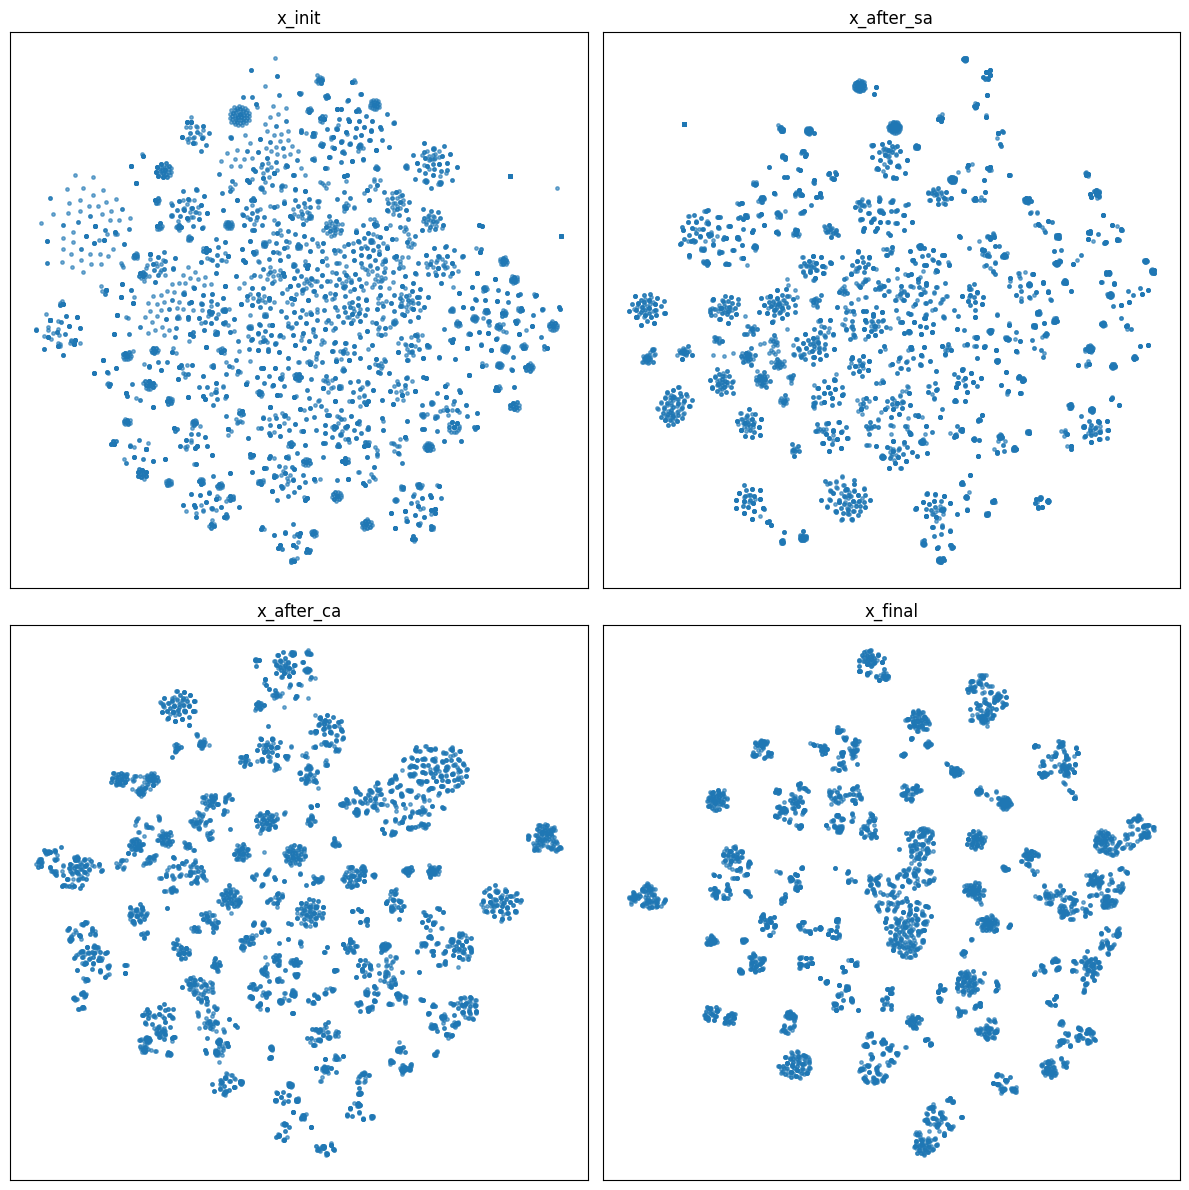

In [52]:
import json
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# ---------------------------
# Config
# ---------------------------
MAX_POINTS_PER_STAGE = 5000   # 安全规模：3000~8000 都可以
RANDOM_SEED = 0

np.random.seed(RANDOM_SEED)

# ---------------------------
# 1. Load saved bank
# ---------------------------
bank = np.load("residual_stream_bank.npz")
vectors = bank["vectors"]   # (N, d)

with open("residual_stream_bank_meta.json", "r", encoding="utf-8") as f:
    meta = json.load(f)

print("Loaded vectors:", vectors.shape)
print("Loaded meta:", len(meta))

# ---------------------------
# 2. Group indices by stage
# ---------------------------
stages = ["x_init", "x_after_sa", "x_after_ca", "x_final"]
stage_to_indices = {s: [] for s in stages}

for i, m in enumerate(meta):
    stage_to_indices[m["stage"]].append(i)

# ---------------------------
# 3. t-SNE per stage (with subsampling)
# ---------------------------
tsne_results = {}

for stage in stages:
    idx_all = np.array(stage_to_indices[stage])
    n_total = len(idx_all)

    if n_total > MAX_POINTS_PER_STAGE:
        idx = np.random.choice(idx_all, size=MAX_POINTS_PER_STAGE, replace=False)
    else:
        idx = idx_all

    X = vectors[idx]

    print(f"{stage}: using {X.shape[0]} / {n_total} points")

    tsne = TSNE(
        n_components=2,
        perplexity=30,
        learning_rate="auto",
        init="pca",
        random_state=RANDOM_SEED,
    )
    Z = tsne.fit_transform(X)
    tsne_results[stage] = Z

# ---------------------------
# 4. Visualization (2x2)
# ---------------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 12))
axes = axes.flatten()

for ax, stage in zip(axes, stages):
    Z = tsne_results[stage]
    ax.scatter(Z[:, 0], Z[:, 1], s=6, alpha=0.6)
    ax.set_title(stage)
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()


In [53]:
import json
import numpy as np
from sklearn.manifold import TSNE

import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ---------------------------
# Config
# ---------------------------
MAX_POINTS_PER_STAGE = 5000   # 3000~15000 都行，越大越慢
RANDOM_SEED = 0
OUT_HTML = "residual_tsne_by_stage.html"

np.random.seed(RANDOM_SEED)

stages = ["x_init", "x_after_sa", "x_after_ca", "x_final"]

# ---------------------------
# 1) Load bank
# ---------------------------
bank = np.load("residual_stream_bank.npz")
vectors = bank["vectors"]  # (N, d)

with open("residual_stream_bank_meta.json", "r", encoding="utf-8") as f:
    meta = json.load(f)

assert len(meta) == vectors.shape[0], "meta length != vectors rows; index alignment broken."

print("Loaded vectors:", vectors.shape)
print("Loaded meta:", len(meta))

# ---------------------------
# 2) Group indices by stage
# ---------------------------
stage_to_indices = {s: [] for s in stages}
for i, m in enumerate(meta):
    stage = m.get("stage")
    if stage in stage_to_indices:
        stage_to_indices[stage].append(i)

# ---------------------------
# 3) Compute t-SNE per stage (with subsampling) + collect hover fields
# ---------------------------
stage_data = {}  # stage -> dict(Z, hover arrays)

for stage in stages:
    idx_all = np.array(stage_to_indices[stage], dtype=np.int64)
    n_total = len(idx_all)

    if n_total == 0:
        print(f"WARNING: stage {stage} has 0 points.")
        continue

    if n_total > MAX_POINTS_PER_STAGE:
        idx = np.random.choice(idx_all, size=MAX_POINTS_PER_STAGE, replace=False)
    else:
        idx = idx_all

    X = vectors[idx]
    meta_sub = [meta[int(i)] for i in idx]

    print(f"{stage}: using {X.shape[0]} / {n_total} points for t-SNE")

    tsne = TSNE(
        n_components=2,
        perplexity=30,
        learning_rate="auto",
        init="pca",
        random_state=RANDOM_SEED,
    )
    Z = tsne.fit_transform(X)

    # Hover fields
    pred_tok = [m.get("pred_next_tok", "") for m in meta_sub]
    pred_id  = [m.get("pred_next_id", -1) for m in meta_sub]
    layer    = [m.get("layer", -1) for m in meta_sub]
    step     = [m.get("step", -1) for m in meta_sub]
    preflen  = [m.get("prefix_len", -1) for m in meta_sub]
    img      = [m.get("img", "") for m in meta_sub]

    stage_data[stage] = {
        "Z": Z,
        "pred_tok": pred_tok,
        "pred_id": pred_id,
        "layer": layer,
        "step": step,
        "preflen": preflen,
        "img": img,
    }

# ---------------------------
# 4) Plotly 2x2 interactive subplots + save HTML
# ---------------------------
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=stages,
    horizontal_spacing=0.06,
    vertical_spacing=0.08
)

stage_to_subplot = {
    "x_init": (1, 1),
    "x_after_sa": (1, 2),
    "x_after_ca": (2, 1),
    "x_final": (2, 2),
}

for stage in stages:
    if stage not in stage_data:
        continue

    r, c = stage_to_subplot[stage]
    Z = stage_data[stage]["Z"]

    # customdata columns used in hovertemplate
    customdata = np.stack([
        stage_data[stage]["pred_tok"],
        stage_data[stage]["pred_id"],
        stage_data[stage]["layer"],
        stage_data[stage]["step"],
        stage_data[stage]["preflen"],
        stage_data[stage]["img"],
    ], axis=1)

    trace = go.Scattergl(
        x=Z[:, 0],
        y=Z[:, 1],
        mode="markers",
        marker=dict(size=5, opacity=0.65),
        customdata=customdata,
        hovertemplate=(
            "<b>stage</b>: " + stage + "<br>"
            "<b>pred_next_tok</b>: %{customdata[0]}<br>"
            "<b>pred_next_id</b>: %{customdata[1]}<br>"
            "<b>layer</b>: %{customdata[2]}<br>"
            "<b>step</b>: %{customdata[3]}<br>"
            "<b>prefix_len</b>: %{customdata[4]}<br>"
            "<b>img</b>: %{customdata[5]}<br>"
            "<extra></extra>"
        ),
        name=stage
    )
    fig.add_trace(trace, row=r, col=c)

# Clean axes (like your matplotlib version)
for r in [1, 2]:
    for c in [1, 2]:
        fig.update_xaxes(showticklabels=False, zeroline=False, row=r, col=c)
        fig.update_yaxes(showticklabels=False, zeroline=False, row=r, col=c)

fig.update_layout(
    title="t-SNE of residual stream by stage (hover shows next token)",
    height=950,
    width=950,
    showlegend=False,
)

fig.write_html(OUT_HTML, include_plotlyjs="cdn")
print("Saved interactive HTML:", OUT_HTML)


Loaded vectors: (757372, 512)
Loaded meta: 757372
x_init: using 5000 / 189343 points for t-SNE
x_after_sa: using 5000 / 189343 points for t-SNE
x_after_ca: using 5000 / 189343 points for t-SNE
x_final: using 5000 / 189343 points for t-SNE
Saved interactive HTML: residual_tsne_by_stage.html


In [56]:
import json
import numpy as np
from sklearn.manifold import TSNE
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# =====================================================
# Config
# =====================================================
MAX_POINTS_PER_STAGE = 10000
RANDOM_SEED = 0
OUT_HTML = "residual_tsne_by_stage_colored.html"

np.random.seed(RANDOM_SEED)

stages = ["x_init", "x_after_sa", "x_after_ca", "x_final"]

# =====================================================
# 1. Token category definition
# =====================================================
TOKEN_CATEGORIES = {
    "FUNCTION": {
        "<PAD>", "<START>", "<END>", ".", ",",
        "the", "a", "an", "is", "are", "of", "and", "with",
        "in", "on", "there", "it", "its", "has", "wears",
        "also", "or", "no"
    },
    "PERSON": {
        "man", "woman", "guy", "lady", "gentleman", "person",
        "his", "her", "female"
    },
    "CLOTHING": {
        "shirt", "t-shirt", "sweater", "pants", "trousers",
        "shorts", "skirt", "tank", "top", "outer", "upper",
        "clothing", "leggings", "socks", "shoes", "suspenders"
    },
    "ATTRIBUTE": {
        "color", "fabric", "cotton", "denim", "leather", "chiffon",
        "long", "short", "medium", "length",
        "solid", "plaid", "stripe", "striped", "lattice",
        "floral", "graphic", "pattern", "patterns",
        "round", "v-shape", "crew", "square",
        "long-sleeve", "short-sleeve", "medium-sleeve",
        "sleeveless", "three-quarter",
        "pure", "mixed", "complicated", "block"
    },
    "BODY_PART": {
        "head", "neck", "waist", "wrist", "finger", "hands"
    },
    "ACCESSORY": {
        "hat", "belt", "glasses", "eyeglasses", "sunglasses",
        "ring", "neckwear"
    }
}

CATEGORY_ORDER = [
    "FUNCTION", "PERSON", "CLOTHING",
    "ATTRIBUTE", "BODY_PART", "ACCESSORY", "OTHER"
]

CATEGORY_COLOR = {
    "FUNCTION": "#00ffe5",
    "PERSON": "#e41a1c",
    "CLOTHING": "#377eb8",
    "ATTRIBUTE": "#4daf4a",
    "BODY_PART": "#984ea3",
    "ACCESSORY": "#ff7f00",
    "OTHER": "#bbbbbb"
}

def classify_token(tok: str) -> str:
    for cat, vocab in TOKEN_CATEGORIES.items():
        if tok in vocab:
            return cat
    return "OTHER"

# =====================================================
# 2. Load bank
# =====================================================
bank = np.load("residual_stream_bank.npz")
vectors = bank["vectors"]

with open("residual_stream_bank_meta.json", "r", encoding="utf-8") as f:
    meta = json.load(f)

# =====================================================
# 3. Group indices by stage
# =====================================================
stage_to_indices = {s: [] for s in stages}
for i, m in enumerate(meta):
    stage = m["stage"]
    if stage in stage_to_indices:
        stage_to_indices[stage].append(i)

# =====================================================
# 4. t-SNE per stage + category coloring
# =====================================================
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=stages,
    horizontal_spacing=0.06,
    vertical_spacing=0.08
)

stage_to_subplot = {
    "x_init": (1, 1),
    "x_after_sa": (1, 2),
    "x_after_ca": (2, 1),
    "x_final": (2, 2),
}

for stage in stages:
    idx_all = np.array(stage_to_indices[stage])
    if len(idx_all) > MAX_POINTS_PER_STAGE:
        idx = np.random.choice(idx_all, size=MAX_POINTS_PER_STAGE, replace=False)
    else:
        idx = idx_all

    X = vectors[idx]
    meta_sub = [meta[int(i)] for i in idx]

    tsne = TSNE(
        n_components=2,
        perplexity=30,
        learning_rate="auto",
        init="pca",
        random_state=RANDOM_SEED,
    )
    Z = tsne.fit_transform(X)

    # classify tokens
    cats = [classify_token(m["pred_next_tok"]) for m in meta_sub]

    r, c = stage_to_subplot[stage]

    for cat in CATEGORY_ORDER:
        mask = [i for i, x in enumerate(cats) if x == cat]
        if not mask:
            continue

        fig.add_trace(
            go.Scattergl(
                x=Z[mask, 0],
                y=Z[mask, 1],
                mode="markers",
                marker=dict(
                    size=5,
                    opacity=0.65,
                    color=CATEGORY_COLOR[cat]
                ),
                name=cat,
                hovertemplate=(
                    "<b>stage</b>: " + stage + "<br>"
                    "<b>category</b>: " + cat + "<br>"
                    "<b>token</b>: %{text}<br>"
                    "<extra></extra>"
                ),
                text=[meta_sub[i]["pred_next_tok"] for i in mask],
                showlegend=(stage == "x_init")
            ),
            row=r, col=c
        )

# =====================================================
# 5. Layout + save
# =====================================================
for r in [1, 2]:
    for c in [1, 2]:
        fig.update_xaxes(showticklabels=False, zeroline=False, row=r, col=c)
        fig.update_yaxes(showticklabels=False, zeroline=False, row=r, col=c)

fig.update_layout(
    title="t-SNE of residual stream colored by predicted token category",
    height=950,
    width=950,
    legend_title="Token Category"
)

fig.write_html(OUT_HTML, include_plotlyjs="cdn")
print("Saved:", OUT_HTML)


Saved: residual_tsne_by_stage_colored.html


## 实验3：对所有的残差写入向量（对last token而言），分析其是否只占据512dim中的某个子空间。尝试分析子空间特征
## 前面说了，我们存了一堆forward过程的中间向量。此处，我们分析残差写入向量的特征。
## 首先，我们依残差写入位置分类，分析每个位置的残差写入向量占据的子空间
## 然后，我们依子块分类（比如SA1和SA2都属于一类），分析残差写入向量占据的子空间
## 最后，我们全都混在一块，分析残差写入占据的子空间
## 对于“首先，其次，最后”的三堆向量，我们都可以做PCA，以M为阈值做方差解释率截断，去近似看看子空间维度
## 同时，可以尝试寻求手段分析子空间相似度，不同的子空间是否一致
## 子空间方向有无可解释性，比如施加子空间方向，能引导logit

In [73]:
import numpy as np
from typing import List, Dict, Any, Tuple
from collections import defaultdict

@torch.no_grad()
def collect_residual_write_bank(
    sample_indices: List[int],
    max_steps: int = 128,
    layers_to_use: List[int] | None = None,
) -> Tuple[np.ndarray, List[Dict[str, Any]]]:
    """
    Collect last-token residual WRITE vectors:
      r_sa = layer.last_sa
      r_ca = layer.last_ca
      r_ffn = layer.last_ffn

    Returns:
      vectors: (N, d_model) float32
      meta: list of dict describing each vector
    """
    model.eval()
    enable_recording(model, True)

    all_vecs = []
    all_meta = []

    for si in sample_indices:
        item = test_data[si]
        img_name = item["img"]

        x_img = load_image_tensor(img_path, img_name).to(device)
        memory = model.encoder(x_img)

        prefix = [model.start_idx]

        for t in range(max_steps):
            clear_all_records(model)

            captions_in = torch.tensor(prefix, dtype=torch.long, device=device).unsqueeze(0)
            logits = model.decoder(memory, captions_in)
            next_logits = logits[0, -1]
            pred_next_id = int(torch.argmax(next_logits).item())
            pred_next_tok = id2token.get(pred_next_id, f"<UNK_ID_{pred_next_id}>")

            for li, layer in enumerate(model.decoder.layers):
                if layers_to_use is not None and li not in layers_to_use:
                    continue

                # last token write vectors (each is (1,d))
                mapping = {
                    "SA": layer.last_sa,
                    "CA": layer.last_ca,
                    "FFN": layer.last_ffn,
                }
                for subblock, tens in mapping.items():
                    if tens is None:
                        continue
                    vec = tens[0].detach().to("cpu", dtype=torch.float32).numpy()  # (d,)
                    all_vecs.append(vec)
                    all_meta.append({
                        "sample_idx": si,
                        "img": img_name,
                        "step": t,
                        "prefix_len": len(prefix),
                        "layer": li,
                        "subblock": subblock,
                        "pred_next_id": pred_next_id,
                        "pred_next_tok": pred_next_tok,
                    })

            prefix.append(pred_next_id)
            if pred_next_id == model.end_idx:
                break

    enable_recording(model, False)
    vectors = np.stack(all_vecs, axis=0).astype(np.float32)
    return vectors, all_meta


# ---- choose samples (建议先少量跑通，再加大) ----
num_samples_exp3 = 300
sample_indices_exp3 = list(range(min(num_samples_exp3, len(test_data))))

write_vectors, write_meta = collect_residual_write_bank(
    sample_indices_exp3, max_steps=40, layers_to_use=None
)

print("write_vectors:", write_vectors.shape)
print("example meta:", write_meta[0])


write_vectors: (32505, 512)
example meta: {'sample_idx': 0, 'img': 'WOMEN-Jackets_Coats-id_00007765-03_2_side.jpg', 'step': 0, 'prefix_len': 1, 'layer': 0, 'subblock': 'SA', 'pred_next_id': 3, 'pred_next_tok': 'the'}


In [111]:
from sklearn.decomposition import PCA

def pca_dim_by_variance(X: np.ndarray, thresh: float = 0.95) -> Tuple[int, np.ndarray]:
    """
    Return:
      k: smallest #components such that cumulative explained variance >= thresh
      cum: cumulative explained variance ratio array
    """
    # Centering is implicit in sklearn PCA
    pca = PCA(n_components=min(X.shape[0], X.shape[1]), svd_solver="full", random_state=0)
    pca.fit(X)
    cum = np.cumsum(pca.explained_variance_ratio_)
    k = int(np.searchsorted(cum, thresh) + 1)
    return k, cum

def group_indices_by_key(meta: List[Dict[str, Any]], key_fn):
    groups = defaultdict(list)
    for i, m in enumerate(meta):
        groups[key_fn(m)].append(i)
    return groups

# ---- variance thresholds ----
M_list = [0.7,0.8,0.90, 0.95, 0.99]

# 1) Position groups: (layer, subblock)
pos_groups = group_indices_by_key(write_meta, lambda m: (m["layer"], m["subblock"]))

# 2) Subblock groups: SA / CA / FFN
sb_groups = group_indices_by_key(write_meta, lambda m: m["subblock"])

# 3) Mixed: all
all_group = {"ALL": list(range(len(write_meta)))}

def summarize_pca(groups, vectors, M_list):
    summary = {}
    for gk, idx in groups.items():
        X = vectors[idx]
        if X.shape[0] < 10:
            # 太少点 PCA 不稳定
            continue
        summary[gk] = {}
        for M in M_list:
            k, cum = pca_dim_by_variance(X, thresh=M)
            summary[gk][f"k@{M}"] = k
    return summary

pos_summary = summarize_pca(pos_groups, write_vectors, M_list)
sb_summary  = summarize_pca(sb_groups,  write_vectors, M_list)
all_summary = summarize_pca(all_group,  write_vectors, M_list)

# quick look
list(pos_summary.items())[:3], sb_summary, all_summary


([((0, 'SA'),
   {'k@0.7': 13, 'k@0.8': 20, 'k@0.9': 38, 'k@0.95': 63, 'k@0.99': 147}),
  ((0, 'CA'),
   {'k@0.7': 13, 'k@0.8': 18, 'k@0.9': 26, 'k@0.95': 39, 'k@0.99': 95}),
  ((0, 'FFN'),
   {'k@0.7': 6, 'k@0.8': 9, 'k@0.9': 15, 'k@0.95': 24, 'k@0.99': 76})],
 {'SA': {'k@0.7': 13, 'k@0.8': 20, 'k@0.9': 38, 'k@0.95': 63, 'k@0.99': 147},
  'CA': {'k@0.7': 13, 'k@0.8': 18, 'k@0.9': 26, 'k@0.95': 39, 'k@0.99': 95},
  'FFN': {'k@0.7': 6, 'k@0.8': 9, 'k@0.9': 15, 'k@0.95': 24, 'k@0.99': 76}},
 {'ALL': {'k@0.7': 18, 'k@0.8': 28, 'k@0.9': 49, 'k@0.95': 81, 'k@0.99': 207}})

In [112]:
import os
import numpy as np
import torch
import matplotlib.pyplot as plt

out_path = "fc_out_singular_spectrum.png"

W = model.decoder.fc_out.weight.detach().float().cpu()  # (V, d)
Vocab, d = W.shape

# SVD: W = U diag(s) Vh
# s shape: (min(V,d),) = (V,)
U, s, Vh = torch.linalg.svd(W, full_matrices=False)

s_np = s.numpy()
s_max = float(s_np[0])
fro2 = float((W**2).sum().item())
spec2 = float((s_np[0] ** 2))

# Numerical rank under several thresholds
def num_rank(s, rel_eps):
    thr = rel_eps * s[0]
    return int((s >= thr).sum())

rank_1e2 = num_rank(s_np, 1e-2)
rank_1e3 = num_rank(s_np, 1e-3)
rank_1e4 = num_rank(s_np, 1e-4)

# Stable rank: ||W||_F^2 / ||W||_2^2
stable_rank = fro2 / (s_np[0]**2 + 1e-12)

# Effective rank: exp(H(p)), p_i = s_i / sum s_i
p = s_np / (s_np.sum() + 1e-12)
entropy = -float(np.sum(p * np.log(p + 1e-12)))
effective_rank = float(np.exp(entropy))

print(f"W shape: {Vocab} x {d}")
print(f"rank(W) <= {min(Vocab, d)} (by construction)")
print(f"numerical rank (rel eps=1e-2): {rank_1e2}")
print(f"numerical rank (rel eps=1e-3): {rank_1e3}")
print(f"numerical rank (rel eps=1e-4): {rank_1e4}")
print(f"stable_rank:   {stable_rank:.3f}")
print(f"effective_rank:{effective_rank:.3f}")
print(f"nullspace dim (using eps=1e-3 rank): {d - rank_1e3}")

# Plot singular spectrum
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
ax.plot(np.arange(1, len(s_np)+1), s_np, marker="o", linewidth=1)
ax.set_title("fc_out.weight singular values")
ax.set_xlabel("singular value index")
ax.set_ylabel("sigma")
ax.grid(True, which="major", axis="both")
plt.tight_layout()
plt.savefig(out_path, dpi=200, bbox_inches="tight")
plt.close(fig)

print("Saved:", out_path)


W shape: 109 x 512
rank(W) <= 109 (by construction)
numerical rank (rel eps=1e-2): 109
numerical rank (rel eps=1e-3): 109
numerical rank (rel eps=1e-4): 109
stable_rank:   22.006
effective_rank:101.537
nullspace dim (using eps=1e-3 rank): 403
Saved: fc_out_singular_spectrum.png


In [103]:
# ===== Cell: 1-layer analytic decomposition verification (hidden + logits) =====
import numpy as np
import numpy.linalg as LA
import torch
import torch.nn.functional as F

torch.set_grad_enabled(False)
model.eval()

# -------------------- choose one test example + prefix --------------------
sample_idx = 0
item = test_data[sample_idx]
img_name = item["img"]
cap_ids = [int(x) for x in item["cap_ids"]]

START_ID = 1
END_ID   = 2

# truncate to first <END> to keep it clean
if END_ID in cap_ids:
    cap_ids = cap_ids[:cap_ids.index(END_ID)+1]

# choose a prefix length (must be >=1 and < len(cap_ids))
prefix_len = min(20, len(cap_ids)-1)  # you can change
prefix_ids = cap_ids[:prefix_len]
gt_next_id = cap_ids[prefix_len]
gt_next_tok = id2token.get(gt_next_id, str(gt_next_id))

print("img:", img_name)
print("prefix_len:", prefix_len, "GT next:", gt_next_tok, f"(id={gt_next_id})")

# -------------------- enable recording on the (only) decoder layer --------------------
assert len(model.decoder.layers) == 1, f"Expected 1 layer, got {len(model.decoder.layers)}"
layer = model.decoder.layers[0]
layer.record = True
layer.clear_records()

# -------------------- run forward (teacher forcing prefix) --------------------
x_img = load_image_tensor(img_path, img_name).to(device)   # (1,3,224,224)
memory = model.encoder(x_img)                              # (1,S,d)

captions_in = torch.tensor(prefix_ids, dtype=torch.long, device=device).unsqueeze(0)  # (1,L)
logits_seq = model.decoder(memory, captions_in)            # (1,L,V)
logits_final = logits_seq[0, -1, :]                        # (V,)

# -------------------- fetch recorded vectors --------------------
# all are (1,d) tensors
x_init      = layer.x_init[0]       # (d,)
x_after_sa  = layer.x_after_sa[0]
x_after_ca  = layer.x_after_ca[0]
x_final     = layer.x_final[0]

d_sa  = layer.last_sa[0]            # ΔSA (d,)
d_ca  = layer.last_ca[0]            # ΔCA
d_ffn = layer.last_ffn[0]           # ΔFFN

# -------------------- helper metrics --------------------
def cosine(a: torch.Tensor, b: torch.Tensor) -> float:
    a = a.detach().float().cpu().numpy()
    b = b.detach().float().cpu().numpy()
    na = LA.norm(a) + 1e-12
    nb = LA.norm(b) + 1e-12
    return float((a @ b) / (na * nb))

def rel_err(a: torch.Tensor, b: torch.Tensor) -> float:
    a = a.detach().float().cpu().numpy()
    b = b.detach().float().cpu().numpy()
    denom = LA.norm(a) + 1e-12
    return float(LA.norm(a - b) / denom)

def topk_tokens_from_vec(vec: torch.Tensor, k=5):
    v = vec.detach().float().cpu()
    vals, idx = torch.topk(v, k=min(k, v.numel()))
    out = []
    for val, i in zip(vals.tolist(), idx.tolist()):
        out.append((id2token.get(int(i), str(i)), float(val)))
    return out

# -------------------- verify hidden residual equalities --------------------
print("\n[Hidden residual checks]")
print("SA:  x_after_sa - x_init   ≈ ΔSA")
print("  cos =", cosine(x_after_sa - x_init, d_sa), " rel_err =", rel_err(x_after_sa - x_init, d_sa))
print("CA:  x_after_ca - x_after_sa ≈ ΔCA")
print("  cos =", cosine(x_after_ca - x_after_sa, d_ca), " rel_err =", rel_err(x_after_ca - x_after_sa, d_ca))
print("FFN: x_final - x_after_ca  ≈ ΔFFN")
print("  cos =", cosine(x_final - x_after_ca, d_ffn), " rel_err =", rel_err(x_final - x_after_ca, d_ffn))

# -------------------- verify logits linear contribution equalities --------------------
W = model.decoder.fc_out.weight.detach()   # (V,d)
b = model.decoder.fc_out.bias.detach()     # (V,)

def logits_from_x(x: torch.Tensor) -> torch.Tensor:
    # x: (d,)
    return W @ x + b

logits_init     = logits_from_x(x_init)
logits_after_sa = logits_from_x(x_after_sa)
logits_after_ca = logits_from_x(x_after_ca)
logits_from_final_record = logits_from_x(x_final)

# (sanity) logits computed from recorded final x vs decoder output logits
print("\n[Logits sanity check]")
print("cos(logits_final(from decoder), logits(W*x_final+b)) =",
      cosine(logits_final, logits_from_final_record))
print("rel_err =",
      rel_err(logits_final, logits_from_final_record))

# contributions
dlogit_sa_emp  = logits_after_sa - logits_init
dlogit_ca_emp  = logits_after_ca - logits_after_sa
dlogit_ffn_emp = logits_from_final_record - logits_after_ca

dlogit_sa_theo  = W @ d_sa
dlogit_ca_theo  = W @ d_ca
dlogit_ffn_theo = W @ d_ffn

print("\n[Logits contribution checks: (W x + b) differences ≈ WΔ]")
print("SA:  (logits_after_sa - logits_init) ≈ WΔSA")
print("  cos =", cosine(dlogit_sa_emp, dlogit_sa_theo), " rel_err =", rel_err(dlogit_sa_emp, dlogit_sa_theo))
print("CA:  (logits_after_ca - logits_after_sa) ≈ WΔCA")
print("  cos =", cosine(dlogit_ca_emp, dlogit_ca_theo), " rel_err =", rel_err(dlogit_ca_emp, dlogit_ca_theo))
print("FFN: (logits_final - logits_after_ca) ≈ WΔFFN")
print("  cos =", cosine(dlogit_ffn_emp, dlogit_ffn_theo), " rel_err =", rel_err(dlogit_ffn_emp, dlogit_ffn_theo))

# -------------------- show top tokens driven by each block (WΔ) --------------------
print("\n[Top-5 tokens by WΔ (which tokens each write directly pushes up)]")
print("SA  top5:", topk_tokens_from_vec(dlogit_sa_theo, k=5))
print("CA  top5:", topk_tokens_from_vec(dlogit_ca_theo, k=5))
print("FFN top5:", topk_tokens_from_vec(dlogit_ffn_theo, k=5))

# also show final next-token top5
print("\n[Final next-token top5 (actual decoder logits)]")
print(topk_tokens_from_vec(logits_final, k=5))

# optional: show GT next token logit and its decomposition
gt = int(gt_next_id)
print("\n[GT next-token logit decomposition (scalar)]")
print("logit(gt) total:", float(logits_from_final_record[gt].item()))
print("  base (Wx_init+b):", float(logits_init[gt].item()))
print("  + SA (WΔSA):", float(dlogit_sa_theo[gt].item()))
print("  + CA (WΔCA):", float(dlogit_ca_theo[gt].item()))
print("  + FFN(WΔFFN):", float(dlogit_ffn_theo[gt].item()))


img: WOMEN-Jackets_Coats-id_00007765-03_2_side.jpg
prefix_len: 20 GT next: patterns (id=17)

[Hidden residual checks]
SA:  x_after_sa - x_init   ≈ ΔSA
  cos = 1.0  rel_err = 5.757357612878877e-08
CA:  x_after_ca - x_after_sa ≈ ΔCA
  cos = 1.0  rel_err = 3.6714340012622415e-08
FFN: x_final - x_after_ca  ≈ ΔFFN
  cos = 0.9999999403953552  rel_err = 5.663041235948185e-08

[Logits sanity check]
cos(logits_final(from decoder), logits(W*x_final+b)) = 1.0
rel_err = 6.774076410920316e-08

[Logits contribution checks: (W x + b) differences ≈ WΔ]
SA:  (logits_after_sa - logits_init) ≈ WΔSA
  cos = 0.9999998807907104  rel_err = 1.6991452866932377e-07
CA:  (logits_after_ca - logits_after_sa) ≈ WΔCA
  cos = 1.0000001192092896  rel_err = 8.940232731902142e-08
FFN: (logits_final - logits_after_ca) ≈ WΔFFN
  cos = 1.0000001192092896  rel_err = 1.322823521832106e-07

[Top-5 tokens by WΔ (which tokens each write directly pushes up)]
SA  top5: [('patterns', 4.375255107879639), ('it', 2.1242713928222656),

/home/chenzhican/miniconda3/envs/nndl/lib/python3.10/site-packages/torch/nn/functional.py:6044: UserWarning:

Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.



In [104]:
# ===== Cell: Dataset-level analytic contribution stats for GT next-token =====
import os, random
import numpy as np
import numpy.linalg as LA
import torch
import matplotlib.pyplot as plt

torch.set_grad_enabled(False)
model.eval()

assert len(model.decoder.layers) == 1, f"Expected 1 layer, got {len(model.decoder.layers)}"
layer = model.decoder.layers[0]

START_ID = 1
END_ID   = 2
PAD_ID   = getattr(model, "pad_idx", 0)

# -------------------- config --------------------
N_SAMPLES = 20          # how many images/samples
PREFIX_PER_SAMPLE = 6   # how many prefix lengths per sample
MAX_PREFIX_CAP = 40     # cap to avoid super-long
SEED = 0

OUT_DIR = "analytic_contrib_stats"
os.makedirs(OUT_DIR, exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# -------------------- helper: build contexts --------------------
def build_contexts(data, n_samples, prefix_per_sample, max_prefix_cap=40):
    idxs = list(range(len(data)))
    random.shuffle(idxs)
    idxs = idxs[:n_samples]

    contexts = []
    for sidx in idxs:
        item = data[sidx]
        img = item["img"]
        cap_ids = [int(x) for x in item["cap_ids"]]

        # truncate to first <END>
        if END_ID in cap_ids:
            cap_ids = cap_ids[:cap_ids.index(END_ID)+1]

        maxL = len(cap_ids) - 1
        if maxL < 1:
            continue
        maxL = min(maxL, max_prefix_cap)

        if prefix_per_sample >= maxL:
            lens = list(range(1, maxL+1))
        else:
            lens = np.linspace(1, maxL, prefix_per_sample).round().astype(int).tolist()
            lens = sorted(set([min(maxL, max(1, x)) for x in lens]))

        for Lp in lens:
            prefix_ids = cap_ids[:Lp]
            gt_next_id = cap_ids[Lp]
            contexts.append({
                "sample_idx": int(sidx),
                "img": img,
                "prefix_len": int(Lp),
                "prefix_ids": prefix_ids,
                "gt_next_id": int(gt_next_id),
                "gt_next_tok": id2token.get(int(gt_next_id), str(gt_next_id)),
            })
    return contexts

contexts = build_contexts(test_data, N_SAMPLES, PREFIX_PER_SAMPLE, MAX_PREFIX_CAP)
print("num contexts:", len(contexts))
print("example:", contexts[0] if len(contexts) else None)
assert len(contexts) > 0, "No contexts built."

# -------------------- cache encoder memory per image --------------------
mem_cache = {}

@torch.no_grad()
def encode_memory(img_name):
    x_img = load_image_tensor(img_path, img_name).to(device)
    return model.encoder(x_img)

# -------------------- run forward with recording; collect contributions --------------------
W = model.decoder.fc_out.weight.detach()   # (V,d)
b = model.decoder.fc_out.bias.detach()     # (V,)

def logits_from_x(x):
    return W @ x + b

records = []  # list of dicts per context

for c in contexts:
    if c["img"] not in mem_cache:
        mem_cache[c["img"]] = encode_memory(c["img"])
    mem = mem_cache[c["img"]]

    # enable recording
    layer.record = True
    layer.clear_records()

    captions_in = torch.tensor(c["prefix_ids"], dtype=torch.long, device=device).unsqueeze(0)  # (1,L)
    logits_seq = model.decoder(mem, captions_in)  # (1,L,V)
    logits_final = logits_seq[0, -1, :]          # (V,)

    # fetch recorded
    x_init = layer.x_init[0]
    d_sa   = layer.last_sa[0]
    d_ca   = layer.last_ca[0]
    d_ffn  = layer.last_ffn[0]
    x_final = layer.x_final[0]

    # compute per-block logit contribution vectors
    dlogit_sa  = (W @ d_sa)
    dlogit_ca  = (W @ d_ca)
    dlogit_ffn = (W @ d_ffn)
    base_logit_vec = logits_from_x(x_init)  # Wx_init+b

    y = int(c["gt_next_id"])

    rec = {
        "img": c["img"],
        "sample_idx": c["sample_idx"],
        "prefix_len": c["prefix_len"],
        "gt_next_id": y,
        "gt_next_tok": c["gt_next_tok"],
        "logit_total_y": float(logits_final[y].item()),
        "logit_base_y": float(base_logit_vec[y].item()),
        "logit_sa_y": float(dlogit_sa[y].item()),
        "logit_ca_y": float(dlogit_ca[y].item()),
        "logit_ffn_y": float(dlogit_ffn[y].item()),
        "logit_wxfinal_y": float((logits_from_x(x_final)[y]).item()),
    }
    records.append(rec)

print("collected records:", len(records))

# -------------------- aggregate stats --------------------
tot = np.array([r["logit_total_y"] for r in records], dtype=np.float64)
base= np.array([r["logit_base_y"]  for r in records], dtype=np.float64)
sa  = np.array([r["logit_sa_y"]    for r in records], dtype=np.float64)
ca  = np.array([r["logit_ca_y"]    for r in records], dtype=np.float64)
ffn = np.array([r["logit_ffn_y"]   for r in records], dtype=np.float64)
sumw = sa + ca + ffn

# sanity: total ~ base + sumw
sanity_rel = LA.norm(tot - (base + sumw)) / (LA.norm(tot) + 1e-12)
print("\n[Sanity] rel_err ||total - (base+sa+ca+ffn)|| / ||total|| =", float(sanity_rel))

def describe(name, x):
    print(f"{name:>10s}: mean={x.mean():8.4f}  med={np.median(x):8.4f}  std={x.std():8.4f}  min={x.min():8.4f}  max={x.max():8.4f}")

print("\n[Scalar contribution stats for GT logit]")
describe("total", tot)
describe("base",  base)
describe("SA",    sa)
describe("CA",    ca)
describe("FFN",   ffn)
describe("sumW",  sumw)

# ratio stats (only where total is positive to avoid ratio instability)
mask = tot > 1e-6
if mask.sum() >= 5:
    r_base = base[mask] / tot[mask]
    r_sa   = sa[mask]   / tot[mask]
    r_ca   = ca[mask]   / tot[mask]
    r_ffn  = ffn[mask]  / tot[mask]
    print("\n[Average share of total GT logit (only total>0)]")
    print("count:", int(mask.sum()), "/", len(tot))
    print(f"base share: mean={r_base.mean():.3f} med={np.median(r_base):.3f}")
    print(f"SA   share: mean={r_sa.mean():.3f} med={np.median(r_sa):.3f}")
    print(f"CA   share: mean={r_ca.mean():.3f} med={np.median(r_ca):.3f}")
    print(f"FFN  share: mean={r_ffn.mean():.3f} med={np.median(r_ffn):.3f}")
else:
    print("\n[WARN] Too few contexts with total>0; skip share stats.")

# -------------------- plot 1: stacked bars of mean contributions --------------------
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
means = [sa.mean(), ca.mean(), ffn.mean()]
ax.bar([0], [means[0]], label="SA")
ax.bar([0], [means[1]], bottom=[means[0]], label="CA")
ax.bar([0], [means[2]], bottom=[means[0]+means[1]], label="FFN")
ax.set_xticks([0])
ax.set_xticklabels(["mean WΔ contributions"])
ax.set_ylabel("GT logit contribution")
ax.grid(True, axis="y", linestyle="--", linewidth=0.5, alpha=0.7)
ax.legend()
plt.tight_layout()
p1 = os.path.join(OUT_DIR, "mean_stacked_Wdeltas.png")
plt.savefig(p1, dpi=200, bbox_inches="tight")
plt.close(fig)
print("\nSaved:", p1)

# -------------------- plot 2: base vs sum(write) mean --------------------
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.bar([0], [base.mean()], label="base (Wx_init+b)")
ax.bar([1], [sumw.mean()], label="SA+CA+FFN (sum WΔ)")
ax.set_xticks([0,1])
ax.set_xticklabels(["base", "writes sum"])
ax.set_ylabel("GT logit contribution (mean)")
ax.grid(True, axis="y", linestyle="--", linewidth=0.5, alpha=0.7)
ax.legend()
plt.tight_layout()
p2 = os.path.join(OUT_DIR, "mean_base_vs_writesum.png")
plt.savefig(p2, dpi=200, bbox_inches="tight")
plt.close(fig)
print("Saved:", p2)

# -------------------- plot 3: contribution distributions --------------------
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
for ax, x, name in zip(axes, [sa, ca, ffn], ["SA", "CA", "FFN"]):
    ax.hist(x, bins=30)
    ax.set_title(f"{name} contribution to GT logit")
    ax.set_xlabel("WΔ(gt)")
    ax.set_ylabel("count")
    ax.grid(True, axis="y", linestyle="--", linewidth=0.5, alpha=0.7)
plt.tight_layout()
p3 = os.path.join(OUT_DIR, "hist_Wdelta_contribs.png")
plt.savefig(p3, dpi=200, bbox_inches="tight")
plt.close(fig)
print("Saved:", p3)

# -------------------- save raw table for later --------------------
import pandas as pd
df = pd.DataFrame(records)
csv_path = os.path.join(OUT_DIR, "gt_logit_contrib_records.csv")
df.to_csv(csv_path, index=False)
print("Saved:", csv_path)
print("\n[Done] See folder:", OUT_DIR)


num contexts: 120
example: {'sample_idx': 1523, 'img': 'WOMEN-Tees_Tanks-id_00004126-04_1_front.jpg', 'prefix_len': 1, 'prefix_ids': [1], 'gt_next_id': 30, 'gt_next_tok': 'this'}
collected records: 120

[Sanity] rel_err ||total - (base+sa+ca+ffn)|| / ||total|| = 6.718758997380896e-08

[Scalar contribution stats for GT logit]
     total: mean= 29.6586  med= 30.1666  std= 12.0221  min=  0.1980  max= 57.7267
      base: mean=  2.2855  med=  1.5695  std=  1.9280  min= -0.7614  max= 11.2872
        SA: mean=  5.4683  med=  4.9251  std=  3.3178  min= -5.2166  max= 13.7874
        CA: mean=  5.9357  med=  5.3675  std=  3.8507  min= -2.5847  max= 17.4004
       FFN: mean= 15.9692  med= 14.9473  std= 10.9508  min=  0.1582  max= 40.3199
      sumW: mean= 27.3731  med= 27.3798  std= 11.8246  min= -0.1158  max= 55.6432

[Average share of total GT logit (only total>0)]
count: 120 / 120
base share: mean=0.096 med=0.063
SA   share: mean=0.005 med=0.183
CA   share: mean=0.304 med=0.205
FFN  share: mea

In [105]:
# ===== Cell: Group GT tokens into (structure vs content) and compare SA/CA/FFN contributions =====
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

OUT_DIR = "analytic_contrib_stats"
os.makedirs(OUT_DIR, exist_ok=True)

# ---- load df ----
if "df" in globals() and isinstance(df, pd.DataFrame) and len(df) > 0:
    _df = df.copy()
else:
    csv_path = os.path.join(OUT_DIR, "gt_logit_contrib_records.csv")
    assert os.path.exists(csv_path), f"CSV not found: {csv_path}"
    _df = pd.read_csv(csv_path)

# ---- define token categories ----
STRUCT_TOKENS = {
    # articles / auxiliaries / conjunctions / prepositions
    "the","a","an","is","are","with","and","of","in","on","or","no",
    # pronouns / determiners (treat as structure-ish in this dataset)
    "it","this","there","his","her","its",
    # punctuation / special
    ".",",","<END>","<START>","<PAD>"
}

def token_category(tok: str) -> str:
    return "structure" if tok in STRUCT_TOKENS else "content"

_df["category"] = _df["gt_next_tok"].astype(str).map(token_category)

# ---- numeric columns ----
cols = ["logit_total_y","logit_base_y","logit_sa_y","logit_ca_y","logit_ffn_y"]
for c in cols:
    _df[c] = pd.to_numeric(_df[c], errors="coerce")

# ---- helper: per-group summary ----
def summarize_group(gdf: pd.DataFrame) -> dict:
    total = gdf["logit_total_y"].to_numpy(dtype=np.float64)
    base  = gdf["logit_base_y"].to_numpy(dtype=np.float64)
    sa    = gdf["logit_sa_y"].to_numpy(dtype=np.float64)
    ca    = gdf["logit_ca_y"].to_numpy(dtype=np.float64)
    ffn   = gdf["logit_ffn_y"].to_numpy(dtype=np.float64)

    # shares (avoid unstable divide when total<=0)
    mask = total > 1e-6
    if mask.sum() >= 5:
        shares = {
            "base": float(np.median(base[mask] / total[mask])),
            "SA":   float(np.median(sa[mask]   / total[mask])),
            "CA":   float(np.median(ca[mask]   / total[mask])),
            "FFN":  float(np.median(ffn[mask]  / total[mask])),
        }
    else:
        shares = {"base": np.nan, "SA": np.nan, "CA": np.nan, "FFN": np.nan}

    # dominance among SA/CA/FFN for GT logit contribution
    write_mat = np.stack([sa, ca, ffn], axis=1)  # (N,3)
    dom = np.argmax(write_mat, axis=1)
    dom_counts = {
        "SA":  float((dom == 0).mean()),
        "CA":  float((dom == 1).mean()),
        "FFN": float((dom == 2).mean()),
    }

    # negative rates
    neg_rates = {
        "base_neg": float((base < 0).mean()),
        "SA_neg":   float((sa   < 0).mean()),
        "CA_neg":   float((ca   < 0).mean()),
        "FFN_neg":  float((ffn  < 0).mean()),
        "total_neg":float((total< 0).mean()),
    }

    return {
        "n": int(len(gdf)),
        "means": {
            "total": float(np.mean(total)),
            "base":  float(np.mean(base)),
            "SA":    float(np.mean(sa)),
            "CA":    float(np.mean(ca)),
            "FFN":   float(np.mean(ffn)),
        },
        "shares_median_totalpos": shares,
        "dominance_write": dom_counts,
        "neg_rates": neg_rates,
        "mask_totalpos_n": int(mask.sum()),
    }

summ = {cat: summarize_group(g) for cat, g in _df.groupby("category")}

print("=== Category summary (GT token) ===")
for cat in ["structure", "content"]:
    if cat not in summ:
        print(f"[WARN] no samples for category: {cat}")
        continue
    s = summ[cat]
    print(f"\n[{cat}] n={s['n']}  (total>0 used for shares: {s['mask_totalpos_n']})")
    m = s["means"]
    print(f"  mean total={m['total']:.3f}  base={m['base']:.3f}  SA={m['SA']:.3f}  CA={m['CA']:.3f}  FFN={m['FFN']:.3f}")
    sh = s["shares_median_totalpos"]
    print(f"  median share (total>0): base={sh['base']:.3f}  SA={sh['SA']:.3f}  CA={sh['CA']:.3f}  FFN={sh['FFN']:.3f}")
    d = s["dominance_write"]
    print(f"  dominance among writes (argmax of SA/CA/FFN): SA={d['SA']:.3f}  CA={d['CA']:.3f}  FFN={d['FFN']:.3f}")
    nr = s["neg_rates"]
    print(f"  negative-rate: base={nr['base_neg']:.3f} SA={nr['SA_neg']:.3f} CA={nr['CA_neg']:.3f} FFN={nr['FFN_neg']:.3f} total={nr['total_neg']:.3f}")

# ---- plot: mean contributions (stacked) + median shares ----
cats = [c for c in ["structure", "content"] if c in summ]
x = np.arange(len(cats))

mean_SA  = [summ[c]["means"]["SA"]  for c in cats]
mean_CA  = [summ[c]["means"]["CA"]  for c in cats]
mean_FFN = [summ[c]["means"]["FFN"] for c in cats]
mean_base= [summ[c]["means"]["base"]for c in cats]

share_base = [summ[c]["shares_median_totalpos"]["base"] for c in cats]
share_SA   = [summ[c]["shares_median_totalpos"]["SA"]   for c in cats]
share_CA   = [summ[c]["shares_median_totalpos"]["CA"]   for c in cats]
share_FFN  = [summ[c]["shares_median_totalpos"]["FFN"]  for c in cats]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# left: stacked mean contributions (base + SA + CA + FFN)
ax = axes[0]
ax.bar(x, mean_base, label="base")
ax.bar(x, mean_SA,   bottom=np.array(mean_base), label="SA")
ax.bar(x, mean_CA,   bottom=np.array(mean_base)+np.array(mean_SA), label="CA")
ax.bar(x, mean_FFN,  bottom=np.array(mean_base)+np.array(mean_SA)+np.array(mean_CA), label="FFN")
ax.set_xticks(x)
ax.set_xticklabels(cats)
ax.set_ylabel("Mean contribution to GT logit")
ax.set_title("Mean GT logit decomposition by token category")
ax.grid(True, axis="y", linestyle="--", linewidth=0.5, alpha=0.7)
ax.legend()

# right: stacked median shares (only total>0)
ax = axes[1]
ax.bar(x, share_base, label="base")
ax.bar(x, share_SA,   bottom=np.array(share_base), label="SA")
ax.bar(x, share_CA,   bottom=np.array(share_base)+np.array(share_SA), label="CA")
ax.bar(x, share_FFN,  bottom=np.array(share_base)+np.array(share_SA)+np.array(share_CA), label="FFN")
ax.set_xticks(x)
ax.set_xticklabels(cats)
ax.set_ylim(0, 1)
ax.set_ylabel("Median share of total GT logit (total>0)")
ax.set_title("Median share by token category")
ax.grid(True, axis="y", linestyle="--", linewidth=0.5, alpha=0.7)
ax.legend()

plt.tight_layout()
p = os.path.join(OUT_DIR, "contrib_by_token_category.png")
plt.savefig(p, dpi=200, bbox_inches="tight")
plt.close(fig)
print("\nSaved:", p)

# ---- plot: dominance among SA/CA/FFN writes ----
dom_SA  = [summ[c]["dominance_write"]["SA"]  for c in cats]
dom_CA  = [summ[c]["dominance_write"]["CA"]  for c in cats]
dom_FFN = [summ[c]["dominance_write"]["FFN"] for c in cats]

fig, ax = plt.subplots(1, 1, figsize=(7, 4))
ax.bar(x, dom_SA, label="SA")
ax.bar(x, dom_CA, bottom=np.array(dom_SA), label="CA")
ax.bar(x, dom_FFN,bottom=np.array(dom_SA)+np.array(dom_CA), label="FFN")
ax.set_xticks(x)
ax.set_xticklabels(cats)
ax.set_ylim(0, 1)
ax.set_ylabel("Fraction of contexts")
ax.set_title("Which write dominates GT logit? (argmax of SA/CA/FFN)")
ax.grid(True, axis="y", linestyle="--", linewidth=0.5, alpha=0.7)
ax.legend()
plt.tight_layout()
p2 = os.path.join(OUT_DIR, "dominance_write_by_category.png")
plt.savefig(p2, dpi=200, bbox_inches="tight")
plt.close(fig)
print("Saved:", p2)

# ---- optional: show most frequent GT tokens per category (quick sanity) ----
print("\nTop GT tokens (structure):")
print(_df[_df["category"]=="structure"]["gt_next_tok"].value_counts().head(15))
print("\nTop GT tokens (content):")
print(_df[_df["category"]=="content"]["gt_next_tok"].value_counts().head(15))


=== Category summary (GT token) ===

[structure] n=71  (total>0 used for shares: 71)
  mean total=28.938  base=1.551  SA=5.877  CA=5.736  FFN=15.773
  median share (total>0): base=0.049  SA=0.201  CA=0.215  FFN=0.537
  dominance among writes (argmax of SA/CA/FFN): SA=0.197  CA=0.127  FFN=0.676
  negative-rate: base=0.042 SA=0.028 CA=0.070 FFN=0.000 total=0.000

[content] n=49  (total>0 used for shares: 49)
  mean total=30.703  base=3.349  SA=4.876  CA=6.224  FFN=16.254
  median share (total>0): base=0.100  SA=0.145  CA=0.175  FFN=0.485
  dominance among writes (argmax of SA/CA/FFN): SA=0.061  CA=0.184  FFN=0.755
  negative-rate: base=0.000 SA=0.020 CA=0.000 FFN=0.000 total=0.000

Saved: analytic_contrib_stats/contrib_by_token_category.png
Saved: analytic_contrib_stats/dominance_write_by_category.png

Top GT tokens (structure):
gt_next_tok
the      17
is       10
this      7
<END>     6
a         6
.         6
with      5
her       3
an        2
are       2
there     2
and       2
his  

## 对FFN功能的探究以及is前缀筛选

In [41]:
import os, json, random, types
import numpy as np
import torch
import torch.nn.functional as F

# -----------------------
# Required globals
# -----------------------
for name in ["model", "device", "img_path", "test_data", "load_image_tensor", "id2token"]:
    if name not in globals():
        raise RuntimeError(f"Missing required variable: {name}")

# token2id fallback
if "token2id" not in globals():
    token2id = {v: int(k) for k, v in id2token.items()} if isinstance(id2token, dict) else {}
    print("[INFO] token2id rebuilt from id2token (best-effort).")

IS_ID  = int(token2id.get("is", 6))
END_ID = int(token2id.get("<END>", 2))
print("IS_ID:", IS_ID)

# -----------------------
# Config
# -----------------------
random.seed(0)
np.random.seed(0)
torch.manual_seed(0)

max_prefix_len = 60
max_contexts   = 3000   # is-位置上下文数量（建议先 100~300）
save_npz       = r"out/ca_attn_is_bank.npz"
save_meta      = r"out/ca_attn_is_meta.json"

# -----------------------
# Patch decoder layers to record cross-attn weights (last token)
# We'll store: layer.ca_w_last = (H, S) where S=mem_len
# -----------------------
def wrap_layer_forward_record_ca_weights(layer):
    if getattr(layer, "_record_ca_w_wrapped", False):
        return

    def forward(self, x, memory, tgt_mask=None, tgt_key_padding_mask=None):
        # SA
        sa_input = self.norm_sa(x)
        sa_out, _ = self.self_attn(
            sa_input, sa_input, sa_input,
            attn_mask=tgt_mask,
            key_padding_mask=tgt_key_padding_mask,
            need_weights=False,
        )
        x = x + self.dropout(sa_out)

        # CA: request per-head weights
        ca_input = self.norm_ca(x)
        ca_out, w = self.cross_attn(
            ca_input, memory, memory,
            need_weights=True,
            average_attn_weights=False,  # -> (B, H, L, S)
        )
        # record last token weights if asked
        if getattr(self, "record_ca_w", False):
            # w: (B,H,L,S)
            self.ca_w_last = w[:, :, -1, :].detach()  # (B,H,S)
        x = x + self.dropout(ca_out)

        # FFN
        ffn_input = self.norm_ff(x)
        ffn_out = self.ffn(ffn_input)
        x = x + ffn_out
        return x

    layer.forward = types.MethodType(forward, layer)
    layer._record_ca_w_wrapped = True

for layer in model.decoder.layers:
    wrap_layer_forward_record_ca_weights(layer)

# -----------------------
# Helpers
# -----------------------
@torch.no_grad()
def get_memory(img_name, cache):
    if img_name in cache:
        return cache[img_name]
    x_img = load_image_tensor(img_path, img_name).to(device)
    mem = model.encoder(x_img)  # (1,S,d)
    cache[img_name] = mem
    return mem

def sample_is_contexts(data, max_prefix_len, max_contexts):
    ctx = []
    for si, item in enumerate(data):
        cap = [int(x) for x in item["cap_ids"]]
        # truncate after END (optional)
        if END_ID in cap:
            cap = cap[:cap.index(END_ID)+1]
        T = min(len(cap)-1, max_prefix_len)
        for t in range(1, T+1):
            if cap[t] == IS_ID:
                ctx.append({
                    "sample_idx": si,
                    "img": item["img"],
                    "t": t,
                    "prefix_ids": cap[:t],  # predict position t
                    "prev_tok": id2token.get(str(cap[t-1]), id2token.get(cap[t-1], str(cap[t-1]))),
                })
    random.shuffle(ctx)
    return ctx[:max_contexts]

@torch.no_grad()
def run_decoder_and_collect_ca_weights(mem, prefix_ids):
    # enable recording
    old_flags = []
    for lyr in model.decoder.layers:
        old_flags.append(getattr(lyr, "record_ca_w", False))
        lyr.record_ca_w = True
        lyr.ca_w_last = None

    prefix = torch.tensor(prefix_ids, dtype=torch.long, device=device).unsqueeze(0)  # (1,L)
    _ = model.decoder(mem, prefix)  # forward once; weights are stored in layers

    # collect
    w_list = []
    for lyr in model.decoder.layers:
        if lyr.ca_w_last is None:
            raise RuntimeError("ca_w_last not recorded; patching failed.")
        w_list.append(lyr.ca_w_last[0].float().cpu().numpy())  # (H,S)

    # restore flags
    for lyr, f in zip(model.decoder.layers, old_flags):
        lyr.record_ca_w = f

    return w_list  # length = num_layers, each (H,S)

# -----------------------
# Main: collect bank
# -----------------------
model.eval()
mem_cache = {}

contexts = sample_is_contexts(test_data, max_prefix_len, max_contexts)
print("num is-contexts:", len(contexts))
if len(contexts) == 0:
    raise RuntimeError("No contexts with GT next token == 'is' found.")

# run one to infer shapes
mem0 = get_memory(contexts[0]["img"], mem_cache)
S = int(mem0.shape[1])
H = int(model.decoder.layers[0].cross_attn.num_heads)
L = len(model.decoder.layers)

print(f"memory tokens S={S}, heads H={H}, decoder layers={L}")

# bank: (N, L, H, S)
N = len(contexts)
bank = np.zeros((N, L, H, S), dtype=np.float32)

for i, c in enumerate(contexts):
    mem = get_memory(c["img"], mem_cache)
    w_list = run_decoder_and_collect_ca_weights(mem, c["prefix_ids"])
    for li in range(L):
        bank[i, li] = w_list[li]  # (H,S)

# save
np.savez_compressed(save_npz, bank=bank)
with open(save_meta, "w", encoding="utf-8") as f:
    json.dump({
        "IS_ID": IS_ID,
        "N": N, "L": L, "H": H, "S": S,
        "max_prefix_len": max_prefix_len,
        "contexts": [
            {k: (v if k != "prefix_ids" else len(v)) for k, v in c.items()}  # prefix_ids too long -> store len only
            for c in contexts
        ],
        "note": "bank[n, layer, head, src_token] = cross-attn weight of last token when GT next token is 'is'"
    }, f, ensure_ascii=False, indent=2)
print("Saved:", save_npz, save_meta)
print("bank shape:", bank.shape)


IS_ID: 6
num is-contexts: 3000
memory tokens S=196, heads H=8, decoder layers=1
Saved: out/ca_attn_is_bank.npz out/ca_attn_is_meta.json
bank shape: (3000, 1, 8, 196)


In [42]:
import json, math
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity

bank_path = r"out\ca_attn_is_bank.npz"
meta_path = r"out\ca_attn_is_meta.json"

data = np.load(bank_path)
bank = data["bank"]  # (N,L,H,S)

with open(meta_path, "r", encoding="utf-8") as f:
    meta = json.load(f)

N, L, H, S = bank.shape
print("Loaded bank:", bank.shape)

# -----------------------
# Helpers: reshape to patch grid if possible
# common ViT: S = 197 (CLS + 196 patches=14x14)
# -----------------------
def infer_grid(S):
    # return (has_cls, g) where g*g = #patches
    if S > 1 and int(round(math.sqrt(S-1)))**2 == (S-1):
        return True, int(round(math.sqrt(S-1)))
    if int(round(math.sqrt(S)))**2 == S:
        return False, int(round(math.sqrt(S)))
    return None, None

has_cls, g = infer_grid(S)
print("grid inference:", has_cls, g)

def vec_to_map(v):
    # v: (S,)
    if g is None:
        return None
    if has_cls:
        patches = v[1:]
    else:
        patches = v
    return patches.reshape(g, g)

# choose a layer to analyze (通常后几层更语法化/更直接)
layer_sel = L - 1  # last layer
# average over heads -> (N,S)
A = bank[:, layer_sel].mean(axis=1)  # (N,S)

# -----------------------
# 1) Mean attention map (and CLS mass if present)
# -----------------------
mean_vec = A.mean(axis=0)  # (S,)
cls_mass = float(mean_vec[0]) if has_cls else None
print("mean CLS mass:", cls_mass)

mean_map = vec_to_map(mean_vec)

fig = plt.figure(figsize=(10, 4))
ax1 = fig.add_subplot(1, 2, 1)
ax1.plot(mean_vec)
ax1.set_title(f"Layer {layer_sel}: mean attn weights over src tokens")
ax1.set_xlabel("src token index")
ax1.grid(True)

ax2 = fig.add_subplot(1, 2, 2)
if mean_map is None:
    ax2.text(0.1, 0.5, "Cannot infer patch grid from S", fontsize=12)
    ax2.axis("off")
else:
    im = ax2.imshow(mean_map)
    ax2.set_title(f"Layer {layer_sel}: mean patch attention")
    fig.colorbar(im, ax=ax2, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig("is_ca_mean_attention.png", dpi=200, bbox_inches="tight")
plt.close(fig)
print("Saved: is_ca_mean_attention.png")

# -----------------------
# 2) PCA on stacked attention vectors (N x S)
#    Show top-3 PCs as "pattern modes"
# -----------------------
pca = PCA(n_components=min(10, S), random_state=0)
Z = pca.fit_transform(A)  # (N, k)
evr = pca.explained_variance_ratio_
print("PCA EVR first 5:", evr[:5], "cum:", np.cumsum(evr[:5]))

# plot EVR curve
fig = plt.figure(figsize=(6, 4))
plt.plot(np.arange(1, len(evr)+1), np.cumsum(evr), marker="o")
plt.xlabel("#PC")
plt.ylabel("cumulative explained var")
plt.title(f"Layer {layer_sel}: PCA on attn weights (N={N})")
plt.grid(True)
plt.tight_layout()
plt.savefig("is_ca_pca_evr.png", dpi=200, bbox_inches="tight")
plt.close(fig)
print("Saved: is_ca_pca_evr.png")

# visualize first 3 PCs as patch maps (if possible)
n_show = 3
fig, axes = plt.subplots(1, n_show, figsize=(4*n_show, 4))
for i in range(n_show):
    pc_vec = pca.components_[i]  # (S,)
    pc_map = vec_to_map(pc_vec)
    ax = axes[i]
    if pc_map is None:
        ax.plot(pc_vec)
        ax.set_title(f"PC{i+1} (vector)")
        ax.grid(True)
    else:
        im = ax.imshow(pc_map)
        ax.set_title(f"PC{i+1} (patch mode)")
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig("is_ca_pca_modes.png", dpi=200, bbox_inches="tight")
plt.close(fig)
print("Saved: is_ca_pca_modes.png")

# -----------------------
# 3) Similarity matrix across samples (cosine on attention vectors)
#    If patterns exist, this often reveals block structure
# -----------------------
# (N,N) might be big; subsample for plotting
M = min(N, 120)
idx = np.random.RandomState(0).choice(N, size=M, replace=False)
Sim = cosine_similarity(A[idx])  # (M,M)

fig = plt.figure(figsize=(6, 5))
plt.imshow(Sim, aspect="auto")
plt.title(f"Layer {layer_sel}: cosine similarity (M={M})")
plt.colorbar()
plt.tight_layout()
plt.savefig("is_ca_similarity_matrix.png", dpi=200, bbox_inches="tight")
plt.close(fig)
print("Saved: is_ca_similarity_matrix.png")

# -----------------------
# 4) Simple clustering on PCA space, visualize cluster centroids as maps
# -----------------------
K = 4  # try 3~6
Zk = Z[:, :5]  # use first 5 PCs
km = KMeans(n_clusters=K, random_state=0, n_init=10).fit(Zk)
labels = km.labels_

centroids = []
for k in range(K):
    centroids.append(A[labels == k].mean(axis=0))
sizes = [int((labels == k).sum()) for k in range(K)]
print("cluster sizes:", sizes)

fig, axes = plt.subplots(1, K, figsize=(4*K, 4))
for k in range(K):
    m = vec_to_map(centroids[k])
    ax = axes[k]
    if m is None:
        ax.plot(centroids[k])
        ax.set_title(f"C{k} (n={sizes[k]})")
        ax.grid(True)
    else:
        im = ax.imshow(m)
        ax.set_title(f"C{k} (n={sizes[k]})")
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig("is_ca_cluster_centroids.png", dpi=200, bbox_inches="tight")
plt.close(fig)
print("Saved: is_ca_cluster_centroids.png")

# save a small summary
with open("is_ca_pattern_summary.json", "w", encoding="utf-8") as f:
    json.dump({
        "layer_sel": layer_sel,
        "N": N, "S": S, "H": H, "has_cls": bool(has_cls) if has_cls is not None else None,
        "pca_evr_first10": evr[:10].tolist(),
        "cluster_sizes": sizes,
        "note": "Inspect saved PNGs for mean map, PCA modes, similarity matrix, and cluster centroids."
    }, f, ensure_ascii=False, indent=2)

print("Saved: is_ca_pattern_summary.json")


Loaded bank: (3000, 1, 8, 196)
grid inference: False 14
mean CLS mass: None
Saved: is_ca_mean_attention.png
PCA EVR first 5: [0.14823788 0.11519238 0.07076316 0.03620926 0.02665077] cum: [0.14823788 0.26343027 0.3341934  0.37040266 0.39705345]
Saved: is_ca_pca_evr.png
Saved: is_ca_pca_modes.png
Saved: is_ca_similarity_matrix.png
cluster sizes: [521, 1631, 626, 222]
Saved: is_ca_cluster_centroids.png
Saved: is_ca_pattern_summary.json


In [47]:
import random, math
import numpy as np
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm

# -----------------------
# Safety checks
# -----------------------
for name in ["model", "device", "img_path", "test_data", "load_image_tensor", "id2token"]:
    if name not in globals():
        raise RuntimeError(f"Missing required variable: {name}")

# token2id
if "token2id" not in globals():
    token2id = {v: int(k) for k, v in id2token.items()} if isinstance(id2token, dict) else {}
IS_ID = int(token2id.get("is", -1))
if IS_ID < 0:
    raise RuntimeError("Cannot find token id for 'is' in token2id/id2token.")

# prenorm model: use record_ca_w + ca_w_last
if not (hasattr(model, "decoder") and hasattr(model.decoder, "layers")):
    raise RuntimeError("Expected prenorm decoder with model.decoder.layers")
for layer in model.decoder.layers:
    layer.record_ca_w = True  # crucial

# -----------------------
# Config
# -----------------------
random.seed(1)
np.random.seed(1)
torch.manual_seed(1)

N_samples = 400
min_prefix_len = 2
max_prefix_len = 100

# -----------------------
# Helpers
# -----------------------
def clean_cap_ids(item):
    cap_ids = item.get("cap_ids", None)
    if cap_ids is None:
        return None
    return [int(x) for x in cap_ids]

def sample_contexts_random(data, N, minL=2, maxL=100):
    idxs = list(range(len(data)))
    random.shuffle(idxs)
    contexts = []
    for si in idxs:
        item = data[si]
        cap_ids = clean_cap_ids(item)
        if cap_ids is None or len(cap_ids) < minL + 1:
            continue
        Lmax = min(maxL, len(cap_ids) - 1)
        if Lmax < minL:
            continue
        Lp = random.randint(minL, Lmax)
        contexts.append({
            "img": item["img"],
            "prefix_ids": cap_ids[:Lp],
            "prefix_len": Lp,
            "gt_next_id": int(cap_ids[Lp]),
        })
        if len(contexts) >= N:
            break
    return contexts

def sample_contexts_is(data, N, is_id, minL=2, maxL=100):
    idxs = list(range(len(data)))
    random.shuffle(idxs)
    contexts = []
    for si in idxs:
        item = data[si]
        cap_ids = clean_cap_ids(item)
        if cap_ids is None or len(cap_ids) < minL + 1:
            continue
        max_t = min(maxL, len(cap_ids) - 1)
        candidates = [t for t in range(minL, max_t + 1) if int(cap_ids[t]) == int(is_id)]
        if not candidates:
            continue
        Lp = random.choice(candidates)
        contexts.append({
            "img": item["img"],
            "prefix_ids": cap_ids[:Lp],
            "prefix_len": int(Lp),
            "gt_next_id": int(cap_ids[Lp]),
        })
        if len(contexts) >= N:
            break
    return contexts

def infer_grid(S):
    if S > 1 and int(round(math.sqrt(S - 1)))**2 == (S - 1):
        return True, int(round(math.sqrt(S - 1)))  # has CLS
    if int(round(math.sqrt(S)))**2 == S:
        return False, int(round(math.sqrt(S)))
    return None, None

# cache encoder memory by image
mem_cache = {}

@torch.no_grad()
def get_memory(img_name: str):
    if img_name in mem_cache:
        return mem_cache[img_name]
    x_img = load_image_tensor(img_path, img_name).to(device)  # (1,3,224,224)
    mem = model.encoder(x_img)  # (1,S,d)
    mem_cache[img_name] = mem
    return mem

@torch.no_grad()
def collect_matrix(contexts):
    """
    Returns:
      M: (N,S_src)  where S_src is visual token count in memory
      Each row is head-avg cross-attn weights for the LAST token in prefix.
    """
    rows = []
    for c in tqdm(contexts, desc="Collecting rows", ncols=100):
        mem = get_memory(c["img"])  # (1,S,d)
        prefix_ids = c["prefix_ids"]
        captions_in = torch.tensor(prefix_ids, dtype=torch.long, device=device).unsqueeze(0)  # (1,T)
        _ = model.decoder(mem, captions_in)

        # last layer (you currently have len=1, but keep generic)
        layer = model.decoder.layers[-1]
        w_last = getattr(layer, "ca_w_last", None)  # (B,H,S)
        if w_last is None:
            raise RuntimeError("ca_w_last is None; did you set layer.record_ca_w=True ?")

        a = w_last[0].mean(dim=0)  # (S,) head-avg
        rows.append(a.detach().cpu().numpy())

    return np.stack(rows, axis=0)  # (N,S)

def drop_cls_and_row_normalize(M):
    """
    Your requirement:
    - heatmap rows sum to 1
    - if CLS exists at col 0, drop it (so x-axis is patch tokens)
    """
    N, S = M.shape
    has_cls, g = infer_grid(S)
    P = M[:, 1:] if has_cls else M  # drop CLS if present
    row_sum = P.sum(axis=1, keepdims=True)
    row_sum[row_sum < 1e-12] = 1e-12
    P = P / row_sum
    return P, has_cls, g

def plot_heatmap_and_colsums(P, tag):
    """
    P: (N, S_patch), rows sum to 1
    Heatmap: y=N samples, x=visual tokens, value=attn score
    Line: col_sums[j] = sum_i P[i,j]
    """
    N, S_patch = P.shape

    # Heatmap
    plt.figure(figsize=(10, 7))
    plt.imshow(P, aspect="auto")
    plt.colorbar()
    plt.xlabel("visual token index (patch)")
    plt.ylabel("sample index")
    plt.title(f"{tag} | heatmap (N={N}, rows sum=1)")
    out_hm = f"{tag}_heatmap.png"
    plt.tight_layout()
    plt.savefig(out_hm, dpi=200, bbox_inches="tight")
    plt.close()

    # Column sums line plot
    col_sums = P.sum(axis=0)
    plt.figure(figsize=(10, 3.5))
    plt.plot(np.arange(S_patch), col_sums)
    plt.grid(True)
    plt.xlabel("visual token index (patch)")
    plt.ylabel("sum over samples")
    plt.title(f"{tag} | column sums")
    out_ln = f"{tag}_colsums.png"
    plt.tight_layout()
    plt.savefig(out_ln, dpi=200, bbox_inches="tight")
    plt.close()

    print("Saved:", out_hm, "and", out_ln)
    print("Check row-sum (min/mean/max):",
          float(P.sum(axis=1).min()), float(P.sum(axis=1).mean()), float(P.sum(axis=1).max()))

# -----------------------
# Build two sets: IS-prefix and Random-prefix
# -----------------------
contexts_is = sample_contexts_is(test_data, N_samples, IS_ID, min_prefix_len, max_prefix_len)
contexts_rd = sample_contexts_random(test_data, N_samples, min_prefix_len, max_prefix_len)

print("num contexts (IS):", len(contexts_is))
print("num contexts (Random):", len(contexts_rd))

# Collect attention matrices
M_is = collect_matrix(contexts_is)   # (N,S_src)
M_rd = collect_matrix(contexts_rd)

# Drop CLS (if any) and ensure rows sum to 1
P_is, has_cls_is, g_is = drop_cls_and_row_normalize(M_is)
P_rd, has_cls_rd, g_rd = drop_cls_and_row_normalize(M_rd)

print("IS:  M", M_is.shape, "P", P_is.shape, "has_cls", has_cls_is, "grid", g_is)
print("RND: M", M_rd.shape, "P", P_rd.shape, "has_cls", has_cls_rd, "grid", g_rd)

# Plot
plot_heatmap_and_colsums(P_is, tag="ISprefix400")
plot_heatmap_and_colsums(P_rd, tag="Randomprefix400")

num contexts (IS): 400
num contexts (Random): 400


  warnings.warn(


IS:  M (400, 196) P (400, 196) has_cls False grid 14
RND: M (400, 196) P (400, 196) has_cls False grid 14
Saved: ISprefix400_heatmap.png and ISprefix400_colsums.png
Check row-sum (min/mean/max): 0.9999998807907104 1.0 1.0000001192092896
Saved: Randomprefix400_heatmap.png and Randomprefix400_colsums.png
Check row-sum (min/mean/max): 0.9999998807907104 1.0 1.000000238418579


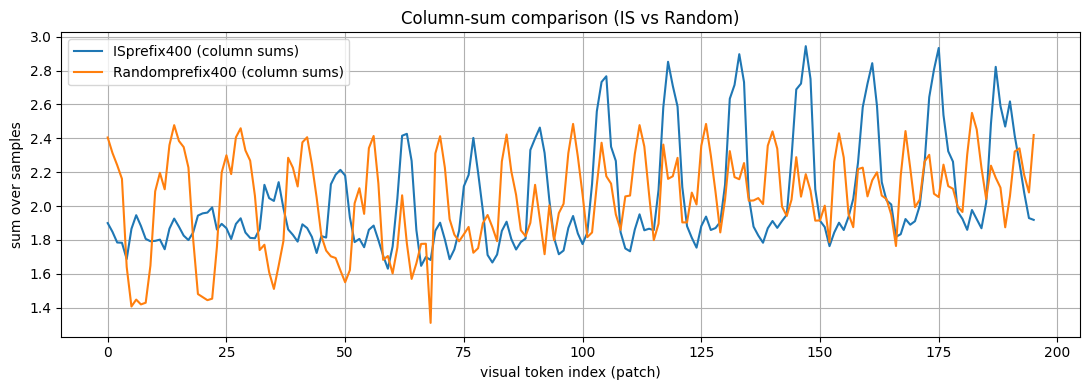

Saved: colsums_compare_is_vs_random.png


In [48]:
import numpy as np
import matplotlib.pyplot as plt

# 依赖上一个单元格已经生成：
#   P_is : (N, S_patch)  每行已归一化 sum=1
#   P_rd : (N, S_patch)  每行已归一化 sum=1
for name in ["P_is", "P_rd"]:
    if name not in globals():
        raise RuntimeError(f"Missing required variable from previous cell: {name}")

col_is = P_is.sum(axis=0)
col_rd = P_rd.sum(axis=0)

S1, S2 = col_is.shape[0], col_rd.shape[0]
S = min(S1, S2)
if S1 != S2:
    print(f"[WARN] token length mismatch: IS={S1}, Random={S2}, plotting first {S} tokens")

x = np.arange(S)

plt.figure(figsize=(11, 4))
plt.plot(x, col_is[:S], label="ISprefix400 (column sums)")
plt.plot(x, col_rd[:S], label="Randomprefix400 (column sums)")
plt.grid(True)
plt.xlabel("visual token index (patch)")
plt.ylabel("sum over samples")
plt.title("Column-sum comparison (IS vs Random)")
plt.legend()
plt.tight_layout()
plt.savefig("colsums_compare_is_vs_random.png", dpi=200, bbox_inches="tight")
plt.show()

print("Saved: colsums_compare_is_vs_random.png")

In [36]:
import os, json, random, types
import numpy as np
import numpy.linalg as LA
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from contextlib import contextmanager
from tqdm import tqdm

# ---------------------------
# Safety checks
# ---------------------------
for name in ["model", "device", "img_path", "test_data", "load_image_tensor", "id2token"]:
    if name not in globals():
        raise RuntimeError(f"Missing required variable: {name}")

if "token2id" not in globals():
    token2id = {v: int(k) for k, v in id2token.items()} if isinstance(id2token, dict) else {}

END_ID = int(token2id.get("<END>", 2))

# ---------------------------
# Config
# ---------------------------
random.seed(1)
np.random.seed(1)
torch.manual_seed(1)

N_samples = 2000
prefix_per_sample = 100
max_prefix_len = 100
topK = 10
FFN_SCALES = [0.0, 0.25, 0.5, 1.0]

save_json = "exp_FFN_gain_control_summary.json"
save_fig  = "exp_FFN_scale_effect.png"

# ---------------------------
# helpers: contexts + memory cache
# ---------------------------
@torch.no_grad()
def sample_contexts(data, N_samples, prefix_per_sample, max_prefix_len):
    idxs = list(range(len(data)))
    random.shuffle(idxs)
    idxs = idxs[:N_samples]
    contexts = []
    for si in idxs:
        item = data[si]
        cap_ids = [int(x) for x in item["cap_ids"]]
        if END_ID in cap_ids:
            cap_ids = cap_ids[:cap_ids.index(END_ID)+1]
        if len(cap_ids) < 3:
            continue
        maxL = min(max_prefix_len, len(cap_ids)-1)
        if maxL < 1:
            continue
        lens = np.linspace(1, maxL, prefix_per_sample).round().astype(int).tolist()
        lens = sorted(list(set([max(1, min(maxL, Lp)) for Lp in lens])))
        for Lp in lens:
            contexts.append({
                "sample_idx": si,
                "img": item["img"],
                "prefix_len": Lp,
                "prefix_ids": cap_ids[:Lp],
                "gt_next_id": int(cap_ids[Lp]),
            })
    return contexts

contexts = sample_contexts(test_data, N_samples, prefix_per_sample, max_prefix_len)
print("num contexts:", len(contexts))
if len(contexts) < 10:
    raise RuntimeError("Too few contexts; increase N_samples.")

mem_cache = {}

@torch.no_grad()
def get_memory(img_name: str):
    if img_name in mem_cache:
        return mem_cache[img_name]
    x_img = load_image_tensor(img_path, img_name).to(device)
    mem_cache[img_name] = model.encoder(x_img)
    return mem_cache[img_name]

# ---------------------------
# 1) Monkey-patch decoder layers: enable recording + FFN scaling
# ---------------------------
FFN_SCALE_GLOBAL = 1.0

@contextmanager
def ffn_scale_ctx(scale: float):
    global FFN_SCALE_GLOBAL
    old = FFN_SCALE_GLOBAL
    FFN_SCALE_GLOBAL = float(scale)
    try:
        yield
    finally:
        FFN_SCALE_GLOBAL = old

def wrap_layer_forward(layer, layer_idx):
    if getattr(layer, "_ffn_scaled_wrapped", False):
        return

    def forward(self, x, memory, tgt_mask=None, tgt_key_padding_mask=None):
        # record init
        if getattr(self, "record", False):
            self.x_init = x[:, -1].detach()

        # SA
        sa_input = self.norm_sa(x)
        sa_out, _ = self.self_attn(
            sa_input, sa_input, sa_input,
            attn_mask=tgt_mask,
            key_padding_mask=tgt_key_padding_mask,
            need_weights=False,
        )
        if getattr(self, "record", False):
            self.last_sa = sa_out[:, -1].detach()
        x = x + self.dropout(sa_out)
        if getattr(self, "record", False):
            self.x_after_sa = x[:, -1].detach()

        # CA
        ca_input = self.norm_ca(x)
        ca_out, _ = self.cross_attn(ca_input, memory, memory, need_weights=False)
        if getattr(self, "record", False):
            self.last_ca = ca_out[:, -1].detach()
        x = x + self.dropout(ca_out)
        if getattr(self, "record", False):
            self.x_after_ca = x[:, -1].detach()

        # FFN (scaled)
        ffn_input = self.norm_ff(x)
        ffn_out = self.ffn(ffn_input)
        if getattr(self, "record", False):
            self.last_ffn = ffn_out[:, -1].detach()

        x = x + (FFN_SCALE_GLOBAL * ffn_out)
        if getattr(self, "record", False):
            self.x_final = x[:, -1].detach()

        return x

    layer.forward = types.MethodType(forward, layer)
    layer._ffn_scaled_wrapped = True

for li, layer in enumerate(model.decoder.layers):
    wrap_layer_forward(layer, li)

# ---------------------------
# 2) run one step and collect write vectors + logits
# ---------------------------
W_unembed = model.decoder.fc_out.weight.detach().float().to(device)  # (V,d)

@torch.no_grad()
def run_step(memory, prefix_ids, record=True):
    # enable record
    old_flags = []
    for layer in model.decoder.layers:
        old_flags.append(getattr(layer, "record", False))
        layer.record = bool(record)

    captions_in = torch.tensor(prefix_ids, dtype=torch.long, device=device).unsqueeze(0)
    logits_seq = model.decoder(memory, captions_in)          # (1,L,V)
    logits = logits_seq[0, -1, :]                           # (V,)
    probs = F.softmax(logits, dim=-1)

    # collect write vectors (last token)
    rec = []
    if record:
        for li, layer in enumerate(model.decoder.layers):
            sa = layer.last_sa[0].float()   # (d,)
            ca = layer.last_ca[0].float()
            ff = layer.last_ffn[0].float()
            rec.append({"layer": li, "sa": sa, "ca": ca, "ffn": ff})

    # restore flags
    for layer, old in zip(model.decoder.layers, old_flags):
        layer.record = old

    return logits, probs, rec

def cosine(a, b, eps=1e-12):
    return float((a @ b).item() / (a.norm().item() * b.norm().item() + eps))

def topk_tokens_from_vec(vec_d, K=10):
    # logit lens: W vec
    z = (W_unembed @ vec_d).detach()
    vals, idx = torch.topk(z, k=min(K, z.numel()))
    idx = idx.detach().cpu().tolist()
    vals = vals.detach().cpu().tolist()
    toks = [(id2token.get(str(i), id2token.get(i, f"<UNK_{i}>")), float(v)) for i, v in zip(idx, vals)]
    return toks, set(idx)

def entropy(probs):
    p = probs.clamp_min(1e-12)
    return float(-(p * p.log()).sum().item())

# ---------------------------
# 3) Alignment test: is r_ffn aligned with r_sa+r_ca ?
# ---------------------------
# cos_list = []
# overlap_list = []
# for c in tqdm(contexts):
#     mem = get_memory(c["img"])
#     with ffn_scale_ctx(1.0):
#         logits, probs, rec = run_step(mem, c["prefix_ids"], record=True)

#     for r in rec:
#         attn = (r["sa"] + r["ca"])
#         ff = r["ffn"]

#         cos_list.append(cosine(ff, attn))

#         # topK overlap under logit lens
#         _, set_attn = topk_tokens_from_vec(attn, K=topK)
#         _, set_ff   = topk_tokens_from_vec(ff,   K=topK)
#         overlap = len(set_attn & set_ff) / max(1, len(set_attn | set_ff))
#         overlap_list.append(float(overlap))

# cos_arr = np.array(cos_list, dtype=np.float32)
# ov_arr  = np.array(overlap_list, dtype=np.float32)

# print("cos(ffn, sa+ca): mean=%.4f  std=%.4f  p10=%.4f  p50=%.4f  p90=%.4f" %
#       (cos_arr.mean(), cos_arr.std(), np.percentile(cos_arr,10), np.percentile(cos_arr,50), np.percentile(cos_arr,90)))
# print("Jaccard(topK) between logit-lens(ffn) and logit-lens(sa+ca): mean=%.4f  std=%.4f" %
#       (ov_arr.mean(), ov_arr.std()))

# ---------------------------
# 4) Scaling test: change FFN scale, see entropy + argmax stability
# ---------------------------
scale_stats = {s: {"entropy": [], "top1prob": [], "argmax": []} for s in FFN_SCALES}

for c in tqdm(contexts):
    mem = get_memory(c["img"])
    prefix = c["prefix_ids"]

    argmax_ref = None
    for s in FFN_SCALES:
        with ffn_scale_ctx(s):
            logits, probs, _ = run_step(mem, prefix, record=False)
        H = entropy(probs)
        top1 = int(torch.argmax(probs).item())
        p1 = float(probs[top1].item())

        scale_stats[s]["entropy"].append(H)
        scale_stats[s]["top1prob"].append(p1)
        scale_stats[s]["argmax"].append(top1)

        if s == 1.0:
            argmax_ref = top1

# compute stability vs scale=1.0
stability = {}
for s in FFN_SCALES:
    if s == 1.0:
        stability[s] = 1.0
        continue
    same = 0
    total = len(contexts)
    for i in range(total):
        same += int(scale_stats[s]["argmax"][i] == scale_stats[1.0]["argmax"][i])
    stability[s] = same / max(1, total)

# aggregate
def mean_std(x):
    x = np.array(x, dtype=np.float32)
    return float(x.mean()), float(x.std())

summary = {
    "scales": {}
}

for s in FFN_SCALES:
    summary["scales"][str(s)] = {
        "entropy_mean,std": mean_std(scale_stats[s]["entropy"]),
        "top1prob_mean,std": mean_std(scale_stats[s]["top1prob"]),
        "argmax_stability_vs_1.0": float(stability[s]),
    }

print(json.dumps(summary, indent=2))

with open(save_json, "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)
print("Saved:", save_json)

# plot
scales = FFN_SCALES
H_means = [summary["scales"][str(s)]["entropy_mean,std"][0] for s in scales]
P1_means = [summary["scales"][str(s)]["top1prob_mean,std"][0] for s in scales]
stab = [summary["scales"][str(s)]["argmax_stability_vs_1.0"] for s in scales]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(scales, H_means, marker="o")
axes[0].set_title("Entropy vs FFN scale")
axes[0].set_xlabel("FFN scale λ")
axes[0].set_ylabel("entropy")
axes[0].grid(True)

axes[1].plot(scales, P1_means, marker="o")
axes[1].set_title("Top1 prob vs FFN scale")
axes[1].set_xlabel("FFN scale λ")
axes[1].set_ylabel("P(top1)")
axes[1].grid(True)

axes[2].plot(scales, stab, marker="o")
axes[2].set_ylim(0, 1)
axes[2].set_title("Argmax stability vs λ=1.0")
axes[2].set_xlabel("FFN scale λ")
axes[2].set_ylabel("stability")
axes[2].grid(True)

plt.tight_layout()
plt.savefig(save_fig, dpi=200, bbox_inches="tight")
plt.close(fig)
print("Saved:", save_fig)

print("\n[Interpretation tip]")
print("If FFN is mainly gain control, then:")
print("  - cos(ffn, sa+ca) and/or topK Jaccard should be noticeably > 0")
print("  - decreasing λ should increase entropy and reduce top1 prob")
print("  - argmax should stay relatively stable for λ in [0.25, 1.0] (often), but may break at λ=0")


num contexts: 93129


100%|██████████| 93129/93129 [16:53<00:00, 91.87it/s] 


{
  "scales": {
    "0.0": {
      "entropy_mean,std": [
        0.8385757207870483,
        0.7077556848526001
      ],
      "top1prob_mean,std": [
        0.7501890659332275,
        0.23107580840587616
      ],
      "argmax_stability_vs_1.0": 0.8510453242276842
    },
    "0.25": {
      "entropy_mean,std": [
        0.39318785071372986,
        0.47084560990333557
      ],
      "top1prob_mean,std": [
        0.857546865940094,
        0.20191590487957
      ],
      "argmax_stability_vs_1.0": 0.9282930129175659
    },
    "0.5": {
      "entropy_mean,std": [
        0.27729806303977966,
        0.4204990863800049
      ],
      "top1prob_mean,std": [
        0.8804970979690552,
        0.19894644618034363
      ],
      "argmax_stability_vs_1.0": 0.9558569296352372
    },
    "1.0": {
      "entropy_mean,std": [
        0.2332882583141327,
        0.39706045389175415
      ],
      "top1prob_mean,std": [
        0.8897562623023987,
        0.19602325558662415
      ],
      "arg